# Predictive Modelling of Social Media Trend Emergence

This notebook presents the implementation and evaluation of the Final Year Project **Predictive Modelling of Social Media Trend Emergence**.

The project uses a Reddit world news dataset to investigate whether early **temporal activity**, **engagement signals**, and **text-based information** can be used to predict whether a social media topic will become an emerging trend in the following week.

The implementation develops an initial keyword-based topic representation before introducing a stronger semantic approach using TF-IDF, Truncated SVD and MiniBatch K-Means clustering. Logistic Regression, Decision Tree and Random Forest classifiers are then evaluated using chronologically separated data.

## 1. Project Aim

**Project aim:** To investigate to what extent temporal activity, engagement signals, and text-based features can be used to predict whether a social media topic will become an emerging trend.

The project evaluates two topic representations. A keyword-based method is first used as an interpretable baseline. A second semantic representation is then developed using TF-IDF, Truncated SVD and MiniBatch K-Means clustering.

## 2. Import Libraries

The prototype uses pandas for data processing, scikit-learn for machine learning, and matplotlib for visualisation.

In [5]:
from pathlib import Path
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Dataset


The uploaded Kaggle dataset is a ZIP file containing two CSV files:

- `posts.csv`
- `comments.csv`

For the first prototype, we use `posts.csv` because it already includes title text, timestamps, score, upvote ratio, and number of comments. The larger `comments.csv` file can be used later for richer text analysis or discussion-network features.

In [8]:
# Check where Jupyter is currently running from.
# If this notebook is inside the WorldNewsData folder, this should be that folder.
print("Current working directory:")
print(Path.cwd())

print("\nFiles in this folder:")
for file in Path.cwd().iterdir():
    print("-", file.name)

Current working directory:
/Users/weilun/Documents/FYP/WorldNewsData

Files in this folder:
- figure_confusion_matrix_decision_tree.png
- posts.csv
- final_confusion_matrix_dummy_classifier.png
- final_confusion_matrix_random_forest.png
- figure_confusion_matrix_dummy_classifier.png
- final_precision_recall_curves.png
- comments.csv
- final_confusion_matrix_decision_tree.png
- final_confusion_matrix_logistic_regression.png
- figure_gantt_chart.png
- figure_confusion_matrix_logistic_regression.png
- .ipynb_checkpoints
- FYP_Reddit_Trend_Emergence_Prototype.ipynb
- FYP_Reddit_Trend_Emergence_Prototype_FinalDev.ipynb


In [9]:
# Since the notebook is in the same folder as the CSV files,
# we can load posts.csv directly by filename.
DATA_DIR = Path(".")
posts_path = DATA_DIR / "posts.csv"
comments_path = DATA_DIR / "comments.csv"

# Check that the required file exists before loading.
if not posts_path.exists():
    raise FileNotFoundError(
        "posts.csv was not found. Make sure this notebook is saved in the same folder as posts.csv."
    )

# comments.csv is not needed for the first prototype, but we check whether it exists.
if comments_path.exists():
    print("comments.csv found. It will not be loaded in this first prototype because it is large.")
else:
    print("comments.csv not found. That is okay for prototype version 1.")

# Load only the columns needed for the prototype.
posts = pd.read_csv(
    posts_path,
    usecols=[
        "post_id", "subreddit", "title", "body", "author", "created_utc",
        "score", "upvote_ratio", "num_comments", "url", "permalink"
    ]
)

print("Posts dataset shape:", posts.shape)
posts.head()

comments.csv found. It will not be loaded in this first prototype because it is large.
Posts dataset shape: (109992, 11)


,post_id,subreddit,title,body,author,created_utc,score,upvote_ratio,num_comments,url,permalink
0,1hqr9cf,worldnews,Journey to Australia,NaN,Future-Engineer5858,2025-01-01 00:00:19,0,0.40,2,https://megaryu-juken.com/archives/2031/jetsta...,https://reddit.com/r/worldnews/comments/1hqr9c...
1,1hqrb3m,worldnews,Spike in Russian flights from Syria to Libyan ...,NaN,Logical_Welder3467,2025-01-01 00:02:40,544,0.95,33,https://edition.cnn.com/2024/12/31/middleeast/...,https://reddit.com/r/worldnews/comments/1hqrb3...
2,1hqrc3h,worldnews,Capybara fight led to death of zoo's beloved a...,NaN,Little_Switch9260,2025-01-01 00:04:09,1,1.00,2,https://www.rnz.co.nz/news/national/537960/cap...,https://reddit.com/r/worldnews/comments/1hqrc3...
3,1hqro9j,worldnews,World’s 500 Richest People Surpassed $10 Trill...,NaN,DappyHayes,2025-01-01 00:23:08,2513,0.96,236,https://www.bloomberg.com/news/articles/2024-1...,https://reddit.com/r/worldnews/comments/1hqro9...
4,1hqrvpn,worldnews,Zimbabwe abolishes death penalty almost 20 yea...,NaN,citytiger,2025-01-01 00:34:53,1609,0.97,54,https://abcnews.go.com/International/wireStory...,https://reddit.com/r/worldnews/comments/1hqrvp...


## 4. Initial Dataset Inspection
This step checks the dataset structure, missing values, date range and engagement statistics

In [11]:
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109992 entries, 0 to 109991
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   post_id       109992 non-null  object 
 1   subreddit     109992 non-null  object 
 2   title         109992 non-null  object 
 3   body          4915 non-null    object 
 4   author        109992 non-null  object 
 5   created_utc   109992 non-null  object 
 6   score         109992 non-null  int64  
 7   upvote_ratio  109992 non-null  float64
 8   num_comments  109992 non-null  int64  
 9   url           105188 non-null  object 
 10  permalink     109992 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 9.2+ MB


In [12]:
# Convert timestamp column into datetime format
posts["created_utc"] = pd.to_datetime(posts["created_utc"], errors="coerce")

print("Number of rows:", len(posts))
print("Date range:", posts["created_utc"].min(), "to", posts["created_utc"].max())
print("Number of unique authors:", posts["author"].nunique())
print("Number of unique subreddits:", posts["subreddit"].nunique())

posts[["score", "upvote_ratio", "num_comments"]].describe()

Number of rows: 109992
Date range: 2025-01-01 00:00:19 to 2026-02-27 23:50:20
Number of unique authors: 25927
Number of unique subreddits: 1


,score,upvote_ratio,num_comments
count,109992.000000,109992.000000,109992.000000
mean,778.517365,0.909460,60.621836
std,3705.489642,0.151914,282.246090
min,0.000000,0.020000,0.000000
25%,1.000000,0.880000,0.000000
50%,1.000000,0.980000,1.000000
75%,103.000000,1.000000,18.000000
max,129555.000000,1.000000,14984.000000


## 5. Basic Cleaning and Time Features

The dataset uses Reddit post timestamps. We convert them to weekly periods because trend emergence is easier to model over time windows rather than individual posts.

For the first prototype:

- Each Reddit post belongs to one week.
- Each post title is used for keyword extraction.
- Engagement is represented using score, upvote ratio, and number of comments.

In [14]:
# Remove rows without a valid timestamp or title.
posts = posts.dropna(subset=["created_utc", "title"]).copy()
posts = posts[posts["title"].astype(str).str.strip() != ""].copy()

# Fill missing engagement values with 0 so aggregation does not fail.
for col in ["score", "upvote_ratio", "num_comments"]:
    posts[col] = pd.to_numeric(posts[col], errors="coerce").fillna(0)

# Weekly time window. Each post is assigned to the start date of its week.
posts["week"] = posts["created_utc"].dt.to_period("W").apply(lambda r: r.start_time)

# Simple title features.
posts["title_length"] = posts["title"].astype(str).str.len()
posts["word_count"] = posts["title"].astype(str).str.split().str.len()

posts[["post_id", "title", "week", "score", "upvote_ratio", "num_comments"]].head()

,post_id,title,week,score,upvote_ratio,num_comments
0,1hqr9cf,Journey to Australia,2024-12-30,0,0.40,2
1,1hqrb3m,Spike in Russian flights from Syria to Libyan ...,2024-12-30,544,0.95,33
2,1hqrc3h,Capybara fight led to death of zoo's beloved a...,2024-12-30,1,1.00,2
3,1hqro9j,World’s 500 Richest People Surpassed $10 Trill...,2024-12-30,2513,0.96,236
4,1hqrvpn,Zimbabwe abolishes death penalty almost 20 yea...,2024-12-30,1609,0.97,54


## 6. Extract Topic Keywords from Titles

A key issue in this project is defining what a "topic" means.

For the first prototype, a topic is represented by a frequently occurring keyword extracted from post titles. This is a practical starting point, but it is not perfect because a single keyword can be ambiguous. For example, a word such as "apple" could refer to a company or a fruit.

Later versions should improve this by grouping semantically similar posts using topic modelling, named entities, or embeddings.

In [16]:
custom_stopwords = {
    "says", "said", "new", "world", "news", "year", "years", "video", "live",
    "reddit", "just", "like", "people", "person", "day", "days", "week", "weeks",
    "breaking", "report", "reports", "saying", "according", "official", "officials",
    "removed", "moderator", "moderators", "comment", "comments", "thread",
    "update", "updates", "latest", "today", "sunday", "monday", "tuesday", "wednesday",
    "thursday", "friday", "saturday"
}


stop_words = set(ENGLISH_STOP_WORDS) | custom_stopwords

MAX_KEYWORDS_PER_POST = 5
TOP_N_KEYWORDS = 500
MIN_KEYWORD_COUNT = 20

# Shared trend-emergence parameters
GROWTH_MULTIPLIER = 2
MIN_NEXT_WEEK_POSTS = 5

def extract_keywords(title, max_terms=5):
    """Extract simple keyword candidates from a post title."""
    tokens = re.findall(r"[a-zA-Z][a-zA-Z]{3,}", str(title).lower())
    tokens = [token for token in tokens if token not in stop_words]

    # Remove duplicates while preserving order.
    unique_tokens = []
    for token in tokens:
        if token not in unique_tokens:
            unique_tokens.append(token)

    return unique_tokens[:max_terms]


posts["keywords"] = posts["title"].apply(extract_keywords)
posts[["title", "keywords"]].head(10)

,title,keywords
0,Journey to Australia,"[journey, australia]"
1,Spike in Russian flights from Syria to Libyan ...,"[spike, russian, flights, syria, libyan]"
2,Capybara fight led to death of zoo's beloved a...,"[capybara, fight, death, beloved, animal]"
3,World’s 500 Richest People Surpassed $10 Trill...,"[richest, surpassed, trillion, wealth]"
4,Zimbabwe abolishes death penalty almost 20 yea...,"[zimbabwe, abolishes, death, penalty, hanging]"
5,New Year’s celebrations around the world,[celebrations]
6,"In letter to Putin, Kim lauds North Korean-Rus...","[letter, putin, lauds, north, korean]"
7,China charged Japanese woman with espionage fo...,"[china, charged, japanese, woman, espionage]"
8,JESUS THE RESTORER OF HOPE 01,"[jesus, restorer, hope]"
9,The websites of several French cities were tak...,"[websites, french, cities, taken, targeted]"


In [17]:
# Define the chronological train/test cutoff before selecting the topic vocabulary

# The final week cannot be used as an observation because there is no following week
eligible_weeks = sorted(posts["week"].unique())[:-1]

# Use the first 80% of eligible weeks as the basis for the training period
cutoff_week = eligible_weeks[int(len(eligible_weeks) * 0.8)]

# Only use posts from weeks whose future label also falls before the test period
vocab_train_mask = (
    posts["week"] + pd.Timedelta(weeks=1)
) < cutoff_week

vocab_train_posts = posts.loc[vocab_train_mask].copy()

# Count keywords using training-period posts only
keyword_counter = Counter(
    keyword
    for keywords in vocab_train_posts["keywords"]
    for keyword in keywords
)

# Rank keywords by frequency within the training period
ranked_top_keywords = [
    keyword
    for keyword, count in keyword_counter.most_common(TOP_N_KEYWORDS)
    if count >= MIN_KEYWORD_COUNT
]

# Convert to a set for faster filtering later
top_keywords = set(ranked_top_keywords)

# Count the number of extracted keywords in every post for diagnostics
posts["num_extracted_keywords"] = posts["keywords"].apply(len)

topic_parameter_summary = pd.DataFrame([
    {
        "Parameter": "Maximum keywords extracted per post",
        "Value": MAX_KEYWORDS_PER_POST
    },
    {
        "Parameter": "Top N keywords considered",
        "Value": TOP_N_KEYWORDS
    },
    {
        "Parameter": "Minimum keyword frequency",
        "Value": MIN_KEYWORD_COUNT
    },
    {
        "Parameter": "Number of selected topic keywords",
        "Value": len(top_keywords)
    },
    {
        "Parameter": "Training vocabulary cutoff",
        "Value": cutoff_week
    },
    {
        "Parameter": "Posts used to build vocabulary",
        "Value": len(vocab_train_posts)
    },
    {
        "Parameter": "Posts with more than one extracted keyword",
        "Value": int((posts["num_extracted_keywords"] > 1).sum())
    },
    {
        "Parameter": "Percentage of posts with more than one extracted keyword",
        "Value": round(
            (posts["num_extracted_keywords"] > 1).mean() * 100,
            2
        )
    }
])

print("Train/test cutoff week:", cutoff_week)
print("Latest week used for vocabulary selection:", vocab_train_posts["week"].max())
print("Posts used to build vocabulary:", len(vocab_train_posts))
print("Selected topic keywords:", len(top_keywords))

print("\nKeyword count per post:")
print(posts["num_extracted_keywords"].describe())

print("\nTop 20 training-period keywords:")
print(keyword_counter.most_common(20))

topic_parameter_summary

Train/test cutoff week: 2025-12-01 00:00:00
Latest week used for vocabulary selection: 2025-11-17 00:00:00
Posts used to build vocabulary: 89066
Selected topic keywords: 500

Keyword count per post:
count    109992.000000
mean          4.616136
std           1.093889
min           0.000000
25%           5.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: num_extracted_keywords, dtype: float64

Top 20 training-period keywords:
[('trump', 11154), ('ukraine', 4901), ('russia', 3993), ('israel', 3298), ('china', 3043), ('russian', 2966), ('india', 2933), ('gaza', 2696), ('iran', 2502), ('putin', 1942), ('canada', 1838), ('israeli', 1793), ('pakistan', 1684), ('president', 1561), ('tariffs', 1515), ('military', 1338), ('hamas', 1323), ('attack', 1241), ('killed', 1235), ('south', 1135)]


,Parameter,Value
0,Maximum keywords extracted per post,5
1,Top N keywords considered,500
2,Minimum keyword frequency,20
3,Number of selected topic keywords,500
4,Training vocabulary cutoff,2025-12-01 00:00:00
5,Posts used to build vocabulary,89066
6,Posts with more than one extracted keyword,105188
7,Percentage of posts with more than one extract...,95.63


### 6.1 Topic Extraction Clarification

The keyword-based method is used as an interpretable baseline topic representation.

Post titles are first converted to lowercase and tokenised using a regular expression. Only alphabetic words containing at least four characters are considered. Standard English stop words and additional Reddit/news-related stop words are removed.

Up to five unique keywords are extracted from each title. Within an individual title, keywords retain their original order of appearance rather than being ranked by importance.

The final topic vocabulary is selected separately. Keywords are ranked according to how frequently they occur in the training-period posts. The 500 most frequent keywords are considered, subject to a minimum frequency of 20 occurrences.

Importantly, the topic vocabulary is constructed using training-period data only. Posts from the later test period do not influence which keywords are selected. This avoids using future information when constructing the predictor variables.

A single post can contain multiple selected keywords and can therefore contribute to multiple topic groups. Similarly, one calendar week can contain many different topic keywords because the modelling unit is one topic keyword during one week.

This keyword-based approach remains a baseline limitation because frequency does not necessarily mean that a word represents a semantically coherent real-world topic. A stronger topic representation will therefore be investigated in the next development stage.

### 6.2 Alternative Topic Representation: TF-IDF Clustering

The keyword-based topic representation provides a simple and interpretable baseline, but individual keywords may not represent complete semantic topics. Posts discussing the same event may use different words, while the same keyword may also appear in unrelated contexts.

To investigate a stronger topic representation, a second approach is implemented using TF-IDF and MiniBatch K-Means clustering.

TF-IDF represents each Reddit post title according to the importance of its words and phrases. MiniBatch K-Means then groups titles with similar TF-IDF representations into clusters. Each cluster is treated as an alternative topic representation.

To avoid information leakage, both the TF-IDF vocabulary and the clustering model are fitted using training-period posts only. The fitted models are then applied to later posts, including the test period.

This method will be compared with the original keyword-based approach rather than replacing it immediately.

In [20]:
# Import tools for the alternative topic representation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans

In [21]:
# Use the same leakage-safe training period
tfidf_train_titles = (
    vocab_train_posts["title"]
    .fillna("")
    .astype(str)
)

all_titles = (
    posts["title"]
    .fillna("")
    .astype(str)
)

print("Titles used to fit TF-IDF:", len(tfidf_train_titles))
print("Total titles to transform:", len(all_titles))
print("Latest training week:", vocab_train_posts["week"].max())
print("Test cutoff week:", cutoff_week)

Titles used to fit TF-IDF: 89066
Total titles to transform: 109992
Latest training week: 2025-11-17 00:00:00
Test cutoff week: 2025-12-01 00:00:00


In [22]:
# Create TF-IDF features from training-period titles only
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    token_pattern=r"(?u)\b[a-zA-Z]{4,}\b",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.80,
    max_features=5000,
    sublinear_tf=True
)

# Learn the TF-IDF vocabulary using training data only
X_train_tfidf_topics = tfidf_vectorizer.fit_transform(tfidf_train_titles)

# Apply the learned vocabulary to all Reddit post titles
X_all_tfidf_topics = tfidf_vectorizer.transform(all_titles)

print("Training TF-IDF matrix shape:", X_train_tfidf_topics.shape)
print("All-post TF-IDF matrix shape:", X_all_tfidf_topics.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))

Training TF-IDF matrix shape: (89066, 5000)
All-post TF-IDF matrix shape: (109992, 5000)
TF-IDF vocabulary size: 5000


In [23]:
# Initial number of semantic topic clusters
N_TOPIC_CLUSTERS = 100

topic_cluster_model = MiniBatchKMeans(
    n_clusters=N_TOPIC_CLUSTERS,
    random_state=42,
    batch_size=2048,
    n_init=10
)

# Fit clusters using training-period titles only
topic_cluster_model.fit(X_train_tfidf_topics)

# Assign every Reddit post to one topic cluster
posts["tfidf_topic_id"] = topic_cluster_model.predict(
    X_all_tfidf_topics
)

print("Requested number of topic clusters:", N_TOPIC_CLUSTERS)
print(
    "Number of topic clusters assigned:",
    posts["tfidf_topic_id"].nunique()
)

print("\nPosts per topic cluster:")
print(
    posts["tfidf_topic_id"]
    .value_counts()
    .describe()
)

Requested number of topic clusters: 100
Number of topic clusters assigned: 100

Posts per topic cluster:
count      100.00000
mean      1099.92000
std       6227.50305
min          1.00000
25%          2.00000
50%          5.00000
75%         10.00000
max      38401.00000
Name: count, dtype: float64


In [24]:
# Extract readable representative terms from each TF-IDF topic cluster
feature_names = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

cluster_centres = topic_cluster_model.cluster_centers_

TOP_TERMS_PER_CLUSTER = 8

cluster_descriptions = []

for cluster_id in range(N_TOPIC_CLUSTERS):
    top_indices = cluster_centres[cluster_id].argsort()[
        -TOP_TERMS_PER_CLUSTER:
    ][::-1]

    top_terms = feature_names[top_indices]

    cluster_descriptions.append({
        "topic_cluster": cluster_id,
        "representative_terms": ", ".join(top_terms),
        "post_count": int(
            (posts["tfidf_topic_id"] == cluster_id).sum()
        )
    })

cluster_summary = pd.DataFrame(cluster_descriptions)

cluster_summary = cluster_summary.sort_values(
    "post_count",
    ascending=False
).reset_index(drop=True)

cluster_summary.head(20)

,topic_cluster,representative_terms,post_count
0,93,"china, russian, know, ukrainian, tariffs, taiw...",38401
1,18,"india, pakistan, government, killed, south, de...",37303
2,5,"trump, ukraine, russia, israel, gaza, iran, pu...",33076
3,25,"worldnews russian, russian invasion, worldnews...",437
4,71,"pope, chosen, american, jokes, judge, watch, b...",56
5,52,"hindu, festival, erupts, india, site, control,...",49
6,32,"windsor, prince andrew, andrew, prince, forced...",46
7,3,"black sabbath, sabbath, metal, icon, ozzy osbo...",38
8,45,"signs executive, trump signs, executive order,...",32
9,62,"support ukraine, maga, support, ukraine, trump...",30


In [25]:
# Inspect example titles from the largest topic clusters
largest_clusters = (
    cluster_summary["topic_cluster"]
    .head(5)
    .tolist()
)

for cluster_id in largest_clusters:
    print("=" * 80)
    print("TOPIC CLUSTER:", cluster_id)

    description = cluster_summary.loc[
        cluster_summary["topic_cluster"] == cluster_id,
        "representative_terms"
    ].iloc[0]

    print("Representative terms:")
    print(description)

    print("\nExample Reddit titles:")

    example_titles = (
        posts.loc[
            posts["tfidf_topic_id"] == cluster_id,
            "title"
        ]
        .drop_duplicates()
        .head(8)
    )

    for title in example_titles:
        print("-", title)

    print()

TOPIC CLUSTER: 93
Representative terms:
china, russian, know, ukrainian, tariffs, taiwan, tariff, hamas

Example Reddit titles:
- Spike in Russian flights from Syria to Libyan desert base as Moscow eyes new Mediterranean hub
- World’s 500 Richest People Surpassed $10 Trillion in Wealth This Year
- New Year’s celebrations around the world 
- JESUS THE RESTORER OF HOPE 01
- Top 10 Most Needed Jobs in the Future || Future Career Opportunities || ...
- Amazon Work From Aome-US
- Official Genshin Impact Community | HoYoLAB
- That girl, mMcKenzie, happy new year not bowing to corporatism <3

TOPIC CLUSTER: 18
Representative terms:
india, pakistan, government, killed, south, dead, president, musk

Example Reddit titles:
- Journey to Australia
- Capybara fight led to death of zoo's beloved animal
- Zimbabwe abolishes death penalty almost 20 years after its last hanging
- China charged Japanese woman with espionage for activities in Japan
- Instead of partying, thousands turn New Year celebrati

### 6.2.7 Diagnose TF-IDF Coverage

The first clustering attempt produced several very large and semantically mixed clusters. Before changing the clustering method, the TF-IDF representation is examined to determine whether some post titles contain little or no usable information after preprocessing.

A title with no non-zero TF-IDF features cannot be meaningfully compared with other titles and may therefore be assigned to an arbitrary cluster.

In [27]:
# Count the number of non-zero TF-IDF features for each post
nonzero_features_per_post = np.asarray(
    (X_all_tfidf_topics != 0).sum(axis=1)
).ravel()

zero_vector_count = int(
    (nonzero_features_per_post == 0).sum()
)

print("Total posts:", len(posts))
print("Posts with zero TF-IDF features:", zero_vector_count)

print(
    "Percentage with zero TF-IDF features:",
    round(zero_vector_count / len(posts) * 100, 2)
)

print("\nNon-zero TF-IDF features per post:")
print(
    pd.Series(nonzero_features_per_post).describe()
)

Total posts: 109992
Posts with zero TF-IDF features: 5230
Percentage with zero TF-IDF features: 4.75

Non-zero TF-IDF features per post:
count    109992.000000
mean          6.375755
std           3.252120
min           0.000000
25%           4.000000
50%           6.000000
75%           8.000000
max          33.000000
dtype: float64


In [28]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

In [29]:
# Reduce the high-dimensional TF-IDF representation
N_SVD_COMPONENTS = 100

svd = TruncatedSVD(
    n_components=N_SVD_COMPONENTS,
    random_state=42
)

# Fit SVD using training-period data only
X_train_svd = svd.fit_transform(
    X_train_tfidf_topics
)

# Transform all posts using the fitted SVD model
X_all_svd = svd.transform(
    X_all_tfidf_topics
)

# Normalise the reduced vectors before clustering
svd_normalizer = Normalizer()

X_train_svd_normalized = svd_normalizer.fit_transform(
    X_train_svd
)

X_all_svd_normalized = svd_normalizer.transform(
    X_all_svd
)

print("Training SVD shape:", X_train_svd_normalized.shape)
print("All-post SVD shape:", X_all_svd_normalized.shape)

print(
    "Explained variance retained:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

Training SVD shape: (89066, 100)
All-post SVD shape: (109992, 100)
Explained variance retained: 0.1565


In [30]:
# Re-cluster the reduced semantic title representation
N_TOPIC_CLUSTERS_V2 = 100

topic_cluster_model_v2 = MiniBatchKMeans(
    n_clusters=N_TOPIC_CLUSTERS_V2,
    random_state=42,
    batch_size=4096,
    n_init=20
)

# Fit using training-period data only
topic_cluster_model_v2.fit(
    X_train_svd_normalized
)

# Assign all posts to the improved topic clusters
posts["tfidf_topic_v2"] = topic_cluster_model_v2.predict(
    X_all_svd_normalized
)

cluster_size_v2 = (
    posts["tfidf_topic_v2"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of clusters:", posts["tfidf_topic_v2"].nunique())

print("\nCluster size distribution:")
print(cluster_size_v2.describe())

print("\nLargest 20 clusters:")
print(cluster_size_v2.head(20))

Number of clusters: 100

Cluster size distribution:
count     100.000000
mean     1099.920000
std       812.083387
min        76.000000
25%       741.250000
50%       957.000000
75%      1238.250000
max      6346.000000
Name: count, dtype: float64

Largest 20 clusters:
tfidf_topic_v2
93    6346
1     4652
61    3910
38    2537
22    2381
80    2174
68    1772
3     1750
67    1698
2     1535
40    1477
23    1431
64    1429
13    1350
35    1335
76    1333
27    1319
5     1319
54    1315
83    1306
Name: count, dtype: int64


### 6.2.9.1 Handle Posts with No Usable TF-IDF Features

A small proportion of post titles contain no terms that remain in the fitted TF-IDF vocabulary. These titles produce zero TF-IDF vectors and therefore contain no usable textual information for semantic topic assignment.

Assigning these posts to a K-Means cluster would be misleading because their cluster membership would not be based on meaningful textual similarity. These posts are therefore assigned an `unassigned` topic value and excluded from the semantic topic-week modelling stage.

The original Reddit posts are not deleted from the dataset. They are only excluded from this alternative semantic topic representation.

In [32]:
# Identify posts that contain at least one usable TF-IDF feature
valid_tfidf_mask = nonzero_features_per_post > 0

print("Total posts:", len(posts))
print("Posts with usable TF-IDF features:", valid_tfidf_mask.sum())
print("Posts excluded from semantic topic assignment:", (~valid_tfidf_mask).sum())

print(
    "Percentage retained:",
    round(valid_tfidf_mask.mean() * 100, 2)
)

Total posts: 109992
Posts with usable TF-IDF features: 104762
Posts excluded from semantic topic assignment: 5230
Percentage retained: 95.25


In [33]:
# Initialise all posts as unassigned
posts["semantic_topic_id"] = -1

# Assign semantic clusters only to posts with usable TF-IDF information
posts.loc[
    valid_tfidf_mask,
    "semantic_topic_id"
] = topic_cluster_model_v2.predict(
    X_all_svd_normalized[valid_tfidf_mask]
)

print(
    "Assigned semantic-topic posts:",
    (posts["semantic_topic_id"] != -1).sum()
)

print(
    "Unassigned posts:",
    (posts["semantic_topic_id"] == -1).sum()
)

print(
    "Number of semantic topics:",
    posts.loc[
        posts["semantic_topic_id"] != -1,
        "semantic_topic_id"
    ].nunique()
)

Assigned semantic-topic posts: 104762
Unassigned posts: 5230
Number of semantic topics: 100


In [34]:
# Get training-period cluster assignments
train_cluster_ids_v2 = topic_cluster_model_v2.predict(
    X_train_svd_normalized
)

training_topic_posts = vocab_train_posts.copy()

training_topic_posts["tfidf_topic_v2"] = (
    train_cluster_ids_v2
)

feature_names = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

TOP_TERMS_PER_CLUSTER = 8

cluster_descriptions_v2 = []

for cluster_id in range(N_TOPIC_CLUSTERS_V2):

    cluster_mask = (
        train_cluster_ids_v2 == cluster_id
    )

    cluster_tfidf = X_train_tfidf_topics[
        cluster_mask
    ]

    if cluster_tfidf.shape[0] == 0:
        continue

    mean_tfidf = np.asarray(
        cluster_tfidf.mean(axis=0)
    ).ravel()

    top_indices = mean_tfidf.argsort()[
        -TOP_TERMS_PER_CLUSTER:
    ][::-1]

    top_terms = feature_names[top_indices]

    cluster_descriptions_v2.append({
        "topic_cluster": cluster_id,
        "representative_terms": ", ".join(top_terms),
        "post_count": int(
            (posts["tfidf_topic_v2"] == cluster_id).sum()
        )
    })

cluster_summary_v2 = pd.DataFrame(
    cluster_descriptions_v2
)

cluster_summary_v2 = (
    cluster_summary_v2
    .sort_values(
        "post_count",
        ascending=False
    )
    .reset_index(drop=True)
)

cluster_summary_v2.head(20)

,topic_cluster,representative_terms,post_count
0,93,"threads, west, bank, west bank, warns, attacks...",6346
1,1,"worldnews, worldnews russian, russian invasion...",4652
2,61,"market, data, price, shows, study, future, dig...",3910
3,38,"woman, prison, british, case, guilty, charged,...",2537
4,22,"trump, order, epstein, executive, department, ...",2381
5,80,"instagram, know, real, music, love, game, trut...",2174
6,68,"city, mexico, country, sudan, border, thousand...",1772
7,3,"china, taiwan, south china, trump, beijing, so...",1750
8,67,"russian, ukraine, sanctions, drones, russian a...",1698
9,2,"tariffs, trump tariffs, trump, china, goods, s...",1535


In [35]:
# Inspect example titles from the largest improved topic clusters
largest_clusters_v2 = (
    cluster_summary_v2["topic_cluster"]
    .head(5)
    .tolist()
)

for cluster_id in largest_clusters_v2:

    print("=" * 80)
    print("TOPIC CLUSTER:", cluster_id)

    description = cluster_summary_v2.loc[
        cluster_summary_v2["topic_cluster"] == cluster_id,
        "representative_terms"
    ].iloc[0]

    print("Representative terms:")
    print(description)

    print("\nExample Reddit titles:")

    example_titles = (
        posts.loc[
            posts["tfidf_topic_v2"] == cluster_id,
            "title"
        ]
        .drop_duplicates()
        .head(8)
    )

    for title in example_titles:
        print("-", title)

    print()

TOPIC CLUSTER: 93
Representative terms:
threads, west, bank, west bank, warns, attacks, zelenskyy, mark

Example Reddit titles:
- 中国製不買運動in新宿駅。安ければで中国製品を買えば、代償を背負うのは次世代ではないでしょうか？
- 2022年6月13下午我妈把伤情鉴定申请书送给湖北省黄石市阳新县政法委王书记后，我妈又把伤情鉴定申请书送到兴国镇政府贪官手里，兴国镇政府贪官还亲... 
- 湖北省黄石市阳新县上街派出所中副队长邓超斌亲口说湖北省和黄石市和阳新县和兴国镇政府的贪官们要用小金库从国家骗钱来了结此事！请问湖北省的小金库和黄... 
- Tata Neu HDFC Bank Credit Card
- 新年明けましておめでとうございます。今年は戦後80年、そして選挙の年です。2600年以上続く祖国日本の存続を守る為に戦った先人の思いを背負い、行動する時が遂に来ました。  ここで植民地になったら246万6千余柱の御英霊の犠牲が無駄になる。この時代に生きる者として強い責任感を持っています。  必ず皇紀2700年(西暦2040年)までは持たせたい。そして次の世代に繋ぎたいです。頑張ります。
- 2025 - Be Faithful
- Palestinian Authority freezes Al Jazeera operations in West Bank
- 【紙上譚彬】賴清德元旦談話 譚彬一起挑X話？中華民國總統消滅中華民國???#賴清德 #元旦談話 #賴清德元旦談話

TOPIC CLUSTER: 1
Representative terms:
worldnews, worldnews russian, russian invasion, invasion ukraine, invasion, america, russian, ukraine

Example Reddit titles:
- Journey to Australia
- /r/WorldNews Live Thread: Russian Invasion of Ukraine Day 1042, Part 1 (Thread #1189)
- Hungary

## 6.3 Build Semantic Topic-Week Records

The improved semantic topic representation is now converted into the same weekly structure used by the keyword baseline.

Each Reddit post with a usable TF-IDF representation belongs to one semantic topic cluster. Posts are grouped by semantic topic and week, and the same temporal, engagement, author and basic text features are calculated.

Using the same feature structure and emergence definition makes it possible to compare the semantic topic representation with the original keyword-based baseline more fairly.

In [37]:
# Keep only posts that received a meaningful semantic topic assignment
semantic_posts = posts.loc[
    posts["semantic_topic_id"] != -1
].copy()

# Add basic title features
semantic_posts["title_length"] = (
    semantic_posts["title"]
    .astype(str)
    .str.len()
)

semantic_posts["word_count"] = (
    semantic_posts["title"]
    .astype(str)
    .str.split()
    .str.len()
)

print("Semantic-topic posts:", semantic_posts.shape[0])
print(
    "Number of semantic topics:",
    semantic_posts["semantic_topic_id"].nunique()
)
print(
    "Number of weeks:",
    semantic_posts["week"].nunique()
)

semantic_posts.head()

Semantic-topic posts: 104762
Number of semantic topics: 100
Number of weeks: 61


,post_id,subreddit,title,body,author,created_utc,score,upvote_ratio,num_comments,url,permalink,week,title_length,word_count,keywords,num_extracted_keywords,tfidf_topic_id,tfidf_topic_v2,semantic_topic_id
0,1hqr9cf,worldnews,Journey to Australia,NaN,Future-Engineer5858,2025-01-01 00:00:19,0,0.40,2,https://megaryu-juken.com/archives/2031/jetsta...,https://reddit.com/r/worldnews/comments/1hqr9c...,2024-12-30,20,3,"[journey, australia]",2,18,1,1
1,1hqrb3m,worldnews,Spike in Russian flights from Syria to Libyan ...,NaN,Logical_Welder3467,2025-01-01 00:02:40,544,0.95,33,https://edition.cnn.com/2024/12/31/middleeast/...,https://reddit.com/r/worldnews/comments/1hqrb3...,2024-12-30,94,16,"[spike, russian, flights, syria, libyan]",5,93,67,67
2,1hqrc3h,worldnews,Capybara fight led to death of zoo's beloved a...,NaN,Little_Switch9260,2025-01-01 00:04:09,1,1.00,2,https://www.rnz.co.nz/news/national/537960/cap...,https://reddit.com/r/worldnews/comments/1hqrc3...,2024-12-30,51,9,"[capybara, fight, death, beloved, animal]",5,18,86,86
3,1hqro9j,worldnews,World’s 500 Richest People Surpassed $10 Trill...,NaN,DappyHayes,2025-01-01 00:23:08,2513,0.96,236,https://www.bloomberg.com/news/articles/2024-1...,https://reddit.com/r/worldnews/comments/1hqro9...,2024-12-30,69,11,"[richest, surpassed, trillion, wealth]",4,93,61,61
4,1hqrvpn,worldnews,Zimbabwe abolishes death penalty almost 20 yea...,NaN,citytiger,2025-01-01 00:34:53,1609,0.97,54,https://abcnews.go.com/International/wireStory...,https://reddit.com/r/worldnews/comments/1hqrvp...,2024-12-30,71,11,"[zimbabwe, abolishes, death, penalty, hanging]",5,18,86,86


In [38]:
# Aggregate posts into semantic topic-week observations
semantic_topic_week = (
    semantic_posts
    .groupby(["semantic_topic_id", "week"])
    .agg(
        post_count=("post_id", "nunique"),
        score_sum=("score", "sum"),
        score_mean=("score", "mean"),
        comments_sum=("num_comments", "sum"),
        comments_mean=("num_comments", "mean"),
        upvote_mean=("upvote_ratio", "mean"),
        unique_authors=("author", "nunique"),
        title_length_mean=("title_length", "mean"),
        word_count_mean=("word_count", "mean")
    )
    .reset_index()
)

# Build a complete topic-week grid
all_semantic_topics = sorted(
    semantic_posts["semantic_topic_id"].unique()
)

all_semantic_weeks = pd.date_range(
    semantic_topic_week["week"].min(),
    semantic_topic_week["week"].max(),
    freq="W-MON"
)

semantic_full_index = pd.MultiIndex.from_product(
    [all_semantic_topics, all_semantic_weeks],
    names=["semantic_topic_id", "week"]
)

semantic_topic_week = (
    semantic_topic_week
    .set_index(["semantic_topic_id", "week"])
    .reindex(semantic_full_index)
    .reset_index()
    .sort_values(["semantic_topic_id", "week"])
)

semantic_numeric_columns = [
    column
    for column in semantic_topic_week.columns
    if column not in ["semantic_topic_id", "week"]
]

semantic_topic_week[semantic_numeric_columns] = (
    semantic_topic_week[semantic_numeric_columns]
    .fillna(0)
)

print(
    "Semantic topic-week table shape:",
    semantic_topic_week.shape
)

semantic_topic_week.head()

Semantic topic-week table shape: (6100, 11)


,semantic_topic_id,week,post_count,score_sum,score_mean,comments_sum,comments_mean,upvote_mean,unique_authors,title_length_mean,word_count_mean
0,0,2024-12-30,6.0,395.0,65.833333,17.0,2.833333,0.878333,6.0,66.833333,10.666667
1,0,2025-01-06,31.0,1788.0,57.677419,158.0,5.096774,0.918065,26.0,73.741935,11.548387
2,0,2025-01-13,8.0,326.0,40.750000,30.0,3.750000,0.790000,7.0,68.125000,10.125000
3,0,2025-01-20,15.0,724.0,48.266667,90.0,6.000000,0.956667,14.0,68.133333,11.400000
4,0,2025-01-27,7.0,293.0,41.857143,53.0,7.571429,0.938571,7.0,83.714286,12.857143


In [39]:
# Create lagged features within each semantic topic
semantic_topic_week["prev_post_count"] = (
    semantic_topic_week
    .groupby("semantic_topic_id")["post_count"]
    .shift(1)
    .fillna(0)
)

semantic_topic_week["prev_score_sum"] = (
    semantic_topic_week
    .groupby("semantic_topic_id")["score_sum"]
    .shift(1)
    .fillna(0)
)

semantic_topic_week["prev_comments_sum"] = (
    semantic_topic_week
    .groupby("semantic_topic_id")["comments_sum"]
    .shift(1)
    .fillna(0)
)

semantic_topic_week["prev_unique_authors"] = (
    semantic_topic_week
    .groupby("semantic_topic_id")["unique_authors"]
    .shift(1)
    .fillna(0)
)

# Calculate growth features
semantic_topic_week["growth_post_count"] = (
    semantic_topic_week["post_count"]
    - semantic_topic_week["prev_post_count"]
)

semantic_topic_week["growth_score_sum"] = (
    semantic_topic_week["score_sum"]
    - semantic_topic_week["prev_score_sum"]
)

semantic_topic_week["growth_comments_sum"] = (
    semantic_topic_week["comments_sum"]
    - semantic_topic_week["prev_comments_sum"]
)

semantic_topic_week["growth_unique_authors"] = (
    semantic_topic_week["unique_authors"]
    - semantic_topic_week["prev_unique_authors"]
)

semantic_topic_week.head()

,semantic_topic_id,week,post_count,score_sum,score_mean,comments_sum,comments_mean,upvote_mean,unique_authors,title_length_mean,word_count_mean,prev_post_count,prev_score_sum,prev_comments_sum,prev_unique_authors,growth_post_count,growth_score_sum,growth_comments_sum,growth_unique_authors
0,0,2024-12-30,6.0,395.0,65.833333,17.0,2.833333,0.878333,6.0,66.833333,10.666667,0.0,0.0,0.0,0.0,6.0,395.0,17.0,6.0
1,0,2025-01-06,31.0,1788.0,57.677419,158.0,5.096774,0.918065,26.0,73.741935,11.548387,6.0,395.0,17.0,6.0,25.0,1393.0,141.0,20.0
2,0,2025-01-13,8.0,326.0,40.750000,30.0,3.750000,0.790000,7.0,68.125000,10.125000,31.0,1788.0,158.0,26.0,-23.0,-1462.0,-128.0,-19.0
3,0,2025-01-20,15.0,724.0,48.266667,90.0,6.000000,0.956667,14.0,68.133333,11.400000,8.0,326.0,30.0,7.0,7.0,398.0,60.0,7.0
4,0,2025-01-27,7.0,293.0,41.857143,53.0,7.571429,0.938571,7.0,83.714286,12.857143,15.0,724.0,90.0,14.0,-8.0,-431.0,-37.0,-7.0


In [40]:
# Get the following week's activity for each semantic topic
semantic_topic_week["next_post_count"] = (
    semantic_topic_week
    .groupby("semantic_topic_id")["post_count"]
    .shift(-1)
)

# Use exactly the same emergence definition as the keyword baseline
semantic_topic_week["emerging_trend"] = (
    (
        semantic_topic_week["next_post_count"]
        >= GROWTH_MULTIPLIER
        * semantic_topic_week["post_count"]
    )
    &
    (
        semantic_topic_week["next_post_count"]
        >= MIN_NEXT_WEEK_POSTS
    )
).astype(int)

# Remove the final observation for each topic
semantic_model_df = (
    semantic_topic_week
    .dropna(subset=["next_post_count"])
    .copy()
)

print(
    "Semantic modelling rows:",
    semantic_model_df.shape[0]
)

print("\nSemantic emerging-trend distribution:")
print(
    semantic_model_df["emerging_trend"]
    .value_counts()
)

print(
    "\nSemantic emerging-trend rate:",
    semantic_model_df["emerging_trend"].mean()
)

Semantic modelling rows: 6000

Semantic emerging-trend distribution:
emerging_trend
0    5064
1     936
Name: count, dtype: int64

Semantic emerging-trend rate: 0.156


In [41]:
semantic_features = [
    "semantic_topic_id",
    "post_count",
    "score_sum",
    "score_mean",
    "comments_sum",
    "comments_mean",
    "upvote_mean",
    "unique_authors",
    "title_length_mean",
    "word_count_mean",
    "prev_post_count",
    "growth_post_count",
    "prev_score_sum",
    "growth_score_sum",
    "prev_comments_sum",
    "growth_comments_sum",
    "prev_unique_authors",
    "growth_unique_authors"
]

semantic_target = "emerging_trend"

# Record the week used to construct each target
semantic_model_df["target_week"] = (
    semantic_model_df["week"]
    + pd.Timedelta(weeks=1)
)

# Use the same cutoff as the keyword baseline
semantic_train_mask = (
    semantic_model_df["target_week"]
    < cutoff_week
)

semantic_test_mask = (
    semantic_model_df["week"]
    >= cutoff_week
)

semantic_boundary_mask = ~(
    semantic_train_mask
    | semantic_test_mask
)

X_train_semantic = semantic_model_df.loc[
    semantic_train_mask,
    semantic_features
]

y_train_semantic = semantic_model_df.loc[
    semantic_train_mask,
    semantic_target
]

X_test_semantic = semantic_model_df.loc[
    semantic_test_mask,
    semantic_features
]

y_test_semantic = semantic_model_df.loc[
    semantic_test_mask,
    semantic_target
]

print("Cutoff week:", cutoff_week)

print(
    "\nSemantic training rows:",
    X_train_semantic.shape[0]
)

print(
    "Semantic testing rows:",
    X_test_semantic.shape[0]
)

print(
    "Semantic boundary rows excluded:",
    semantic_boundary_mask.sum()
)

print(
    "\nSemantic training emerging rate:",
    y_train_semantic.mean()
)

print(
    "Semantic testing emerging rate:",
    y_test_semantic.mean()
)

Cutoff week: 2025-12-01 00:00:00

Semantic training rows: 4700
Semantic testing rows: 1200
Semantic boundary rows excluded: 100

Semantic training emerging rate: 0.15978723404255318
Semantic testing emerging rate: 0.145


## 6.4 Semantic Topic Baseline Modelling

To evaluate whether the semantic topic representation improves trend prediction, the same baseline classifiers used for the keyword-based approach are trained on the semantic topic-week dataset.

Keeping the model settings unchanged makes the comparison more controlled. Any major difference in performance can therefore be investigated in relation to the topic representation rather than changes to the classifier itself.

The semantic topic identifier is treated as a categorical variable, while the remaining temporal, engagement, author and text-related features are treated as numeric variables.

In [43]:
# Separate semantic topic identity from numeric features
semantic_categorical_features = [
    "semantic_topic_id"
]

semantic_numeric_features = [
    feature
    for feature in semantic_features
    if feature != "semantic_topic_id"
]

# Apply scaling to numeric features and one-hot encoding to topic identity
semantic_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            semantic_numeric_features
        ),
        (
            "topic",
            OneHotEncoder(handle_unknown="ignore"),
            semantic_categorical_features
        )
    ]
)

print("Numeric semantic features:", len(semantic_numeric_features))
print("Categorical semantic features:", semantic_categorical_features)

Numeric semantic features: 17
Categorical semantic features: ['semantic_topic_id']


In [44]:
# Use the same model settings as the keyword baseline
semantic_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )
}

semantic_results = {}

for model_name, model in semantic_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocess", semantic_preprocess),
            ("model", model)
        ]
    )

    # Train the model
    pipeline.fit(
        X_train_semantic,
        y_train_semantic
    )

    # Predict the future test period
    predictions = pipeline.predict(
        X_test_semantic
    )

    # Store evaluation results
    semantic_results[model_name] = {
        "pipeline": pipeline,
        "predictions": predictions,
        "accuracy": accuracy_score(
            y_test_semantic,
            predictions
        ),
        "precision": precision_score(
            y_test_semantic,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_semantic,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_semantic,
            predictions,
            zero_division=0
        )
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test_semantic,
            predictions,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.55      0.70      1026
           1       0.24      0.83      0.37       174

    accuracy                           0.59      1200
   macro avg       0.59      0.69      0.53      1200
weighted avg       0.85      0.59      0.65      1200

Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.67      0.78      1026
           1       0.29      0.80      0.43       174

    accuracy                           0.69      1200
   macro avg       0.62      0.74      0.60      1200
weighted avg       0.86      0.69      0.73      1200



In [45]:
# Create a majority-class baseline for the semantic topic dataset
semantic_dummy_pipeline = Pipeline(
    steps=[
        ("preprocess", semantic_preprocess),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

semantic_dummy_pipeline.fit(
    X_train_semantic,
    y_train_semantic
)

semantic_dummy_predictions = (
    semantic_dummy_pipeline.predict(
        X_test_semantic
    )
)

semantic_results["Dummy Classifier"] = {
    "pipeline": semantic_dummy_pipeline,
    "predictions": semantic_dummy_predictions,
    "accuracy": accuracy_score(
        y_test_semantic,
        semantic_dummy_predictions
    ),
    "precision": precision_score(
        y_test_semantic,
        semantic_dummy_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test_semantic,
        semantic_dummy_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test_semantic,
        semantic_dummy_predictions,
        zero_division=0
    )
}

print("=" * 70)
print("Dummy Classifier")
print("=" * 70)

print(
    classification_report(
        y_test_semantic,
        semantic_dummy_predictions,
        zero_division=0
    )
)

Dummy Classifier
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1026
           1       0.00      0.00      0.00       174

    accuracy                           0.85      1200
   macro avg       0.43      0.50      0.46      1200
weighted avg       0.73      0.85      0.79      1200



In [46]:
semantic_results_df = pd.DataFrame([
    {
        "model": model_name,
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"]
    }
    for model_name, result
    in semantic_results.items()
])

semantic_results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.590000,0.238487,0.833333,0.370844
1,Decision Tree,0.685833,0.289855,0.804598,0.426180
2,Dummy Classifier,0.855000,0.000000,0.000000,0.000000


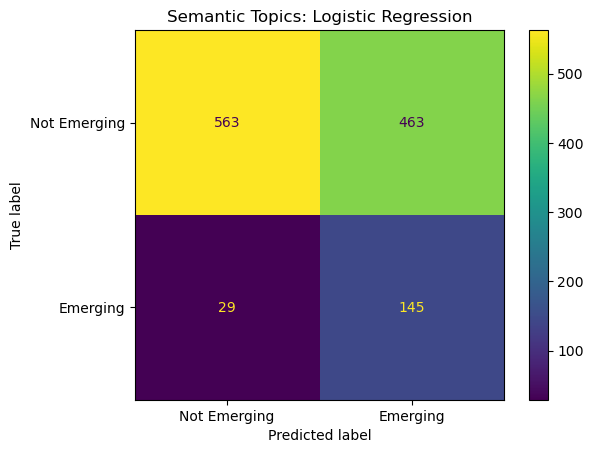

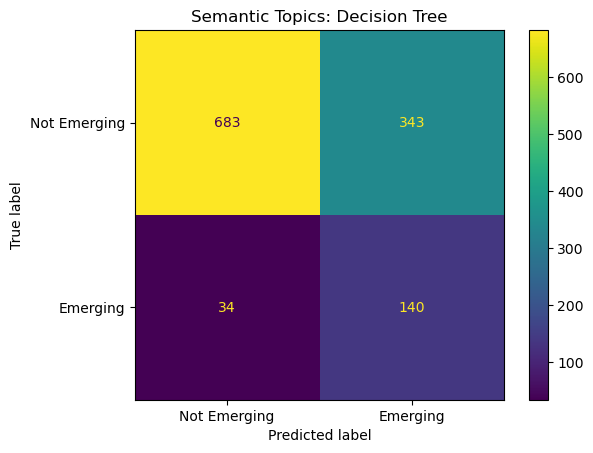

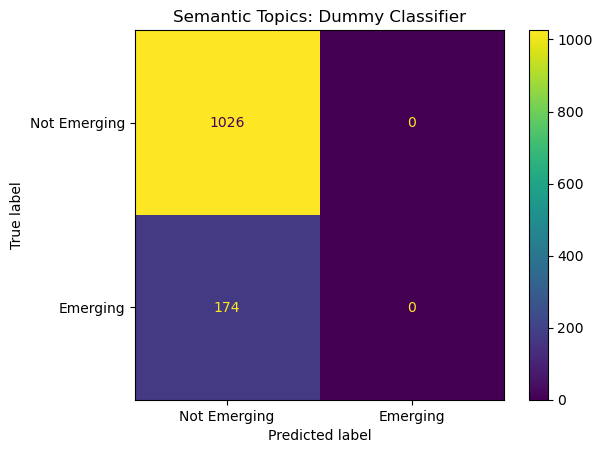

In [47]:
for model_name, result in semantic_results.items():

    cm = confusion_matrix(
        y_test_semantic,
        result["predictions"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Not Emerging",
            "Emerging"
        ]
    )

    disp.plot(
        values_format="d"
    )

    plt.title(
        f"Semantic Topics: {model_name}"
    )

    plt.show()

## 7. Convert Posts into Topic-Week Records

A single Reddit post may contain multiple topic keywords. We therefore create a topic-week table where each row represents one topic keyword during one week.

This allows the model to learn patterns such as:

- how often a topic appears in the current week,
- how much engagement the topic receives,
- whether activity has increased compared with the previous week,
- whether the topic becomes more active in the next week.

In [49]:
# Create one row for each post-keyword pair
keyword_posts = posts[
    ["post_id", "week", "author", "score", "upvote_ratio", "num_comments", "title", "keywords"]
].explode("keywords")

keyword_posts = keyword_posts.rename(columns={"keywords": "topic_keyword"})
keyword_posts = keyword_posts[keyword_posts["topic_keyword"].isin(top_keywords)].copy()

keyword_posts["title_length"] = keyword_posts["title"].astype(str).str.len()
keyword_posts["word_count"] = keyword_posts["title"].astype(str).str.split().str.len()

print("Keyword-post table shape:", keyword_posts.shape)
print("Unique topic keywords after filtering:", keyword_posts["topic_keyword"].nunique())
print("Unique weeks:", keyword_posts["week"].nunique())

keyword_posts.head()

Keyword-post table shape: (232565, 10)
Unique topic keywords after filtering: 500
Unique weeks: 61


,post_id,week,author,score,upvote_ratio,num_comments,title,topic_keyword,title_length,word_count
0,1hqr9cf,2024-12-30,Future-Engineer5858,0,0.40,2,Journey to Australia,australia,20,3
1,1hqrb3m,2024-12-30,Logical_Welder3467,544,0.95,33,Spike in Russian flights from Syria to Libyan ...,russian,94,16
1,1hqrb3m,2024-12-30,Logical_Welder3467,544,0.95,33,Spike in Russian flights from Syria to Libyan ...,syria,94,16
2,1hqrc3h,2024-12-30,Little_Switch9260,1,1.00,2,Capybara fight led to death of zoo's beloved a...,fight,51,9
2,1hqrc3h,2024-12-30,Little_Switch9260,1,1.00,2,Capybara fight led to death of zoo's beloved a...,death,51,9


In [50]:
# Check whether individual posts can belong to multiple selected topic keywords
selected_topic_count_per_post = keyword_posts.groupby("post_id")["topic_keyword"].nunique()

print("Selected topic keywords per post:")
print(selected_topic_count_per_post.describe())

print("\nPosts assigned to more than one selected topic keyword:")
print((selected_topic_count_per_post > 1).sum())

print("\nPercentage of posts assigned to more than one selected topic keyword:")
print(round((selected_topic_count_per_post > 1).mean() * 100, 2))

Selected topic keywords per post:
count    93794.000000
mean         2.479530
std          1.124775
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: topic_keyword, dtype: float64

Posts assigned to more than one selected topic keyword:
72224

Percentage of posts assigned to more than one selected topic keyword:
77.0


In [51]:
# Check how many different topic keywords appear in each week
topics_per_week = keyword_posts.groupby("week")["topic_keyword"].nunique()

print("Number of topic keywords per week:")
print(topics_per_week.describe())

print("\nWeeks with the highest number of topic keywords:")
print(topics_per_week.sort_values(ascending=False).head(10))

Number of topic keywords per week:
count     61.000000
mean     454.032787
std       17.611518
min      411.000000
25%      443.000000
50%      453.000000
75%      469.000000
max      490.000000
Name: topic_keyword, dtype: float64

Weeks with the highest number of topic keywords:
week
2025-05-26    490
2025-03-24    485
2025-03-03    482
2025-03-17    479
2025-04-07    476
2025-03-10    476
2025-03-31    475
2025-01-27    475
2025-02-17    474
2025-02-24    474
Name: topic_keyword, dtype: int64


In [52]:
# Aggregate post-keyword rows into topic-week rows
topic_week = keyword_posts.groupby(["topic_keyword", "week"]).agg(
    post_count=("post_id", "nunique"),
    score_sum=("score", "sum"),
    score_mean=("score", "mean"),
    comments_sum=("num_comments", "sum"),
    comments_mean=("num_comments", "mean"),
    upvote_mean=("upvote_ratio", "mean"),
    unique_authors=("author", "nunique"),
    title_length_mean=("title_length", "mean"),
    word_count_mean=("word_count", "mean")
).reset_index()

# Create a complete topic-week grid so weeks with zero activity are represented
all_weeks = pd.date_range(topic_week["week"].min(), topic_week["week"].max(), freq="W-MON")
full_index = pd.MultiIndex.from_product(
    [sorted(top_keywords), all_weeks],
    names=["topic_keyword", "week"]
)

topic_week = (
    topic_week
    .set_index(["topic_keyword", "week"])
    .reindex(full_index)
    .reset_index()
    .sort_values(["topic_keyword", "week"])
)

numeric_columns = [col for col in topic_week.columns if col not in ["topic_keyword", "week"]]
topic_week[numeric_columns] = topic_week[numeric_columns].fillna(0)

print("Topic-week table shape:", topic_week.shape)
topic_week.head()

Topic-week table shape: (30500, 11)


,topic_keyword,week,post_count,score_sum,score_mean,comments_sum,comments_mean,upvote_mean,unique_authors,title_length_mean,word_count_mean
0,access,2024-12-30,1.0,1.0,1.00,1.0,1.0,1.000,1.0,57.0,8.0
1,access,2025-01-06,4.0,28787.0,7196.75,1060.0,265.0,0.945,4.0,70.5,11.0
2,access,2025-01-13,0.0,0.0,0.00,0.0,0.0,0.000,0.0,0.0,0.0
3,access,2025-01-20,1.0,4634.0,4634.00,484.0,484.0,0.960,1.0,45.0,7.0
4,access,2025-01-27,1.0,4.0,4.00,2.0,2.0,0.750,1.0,68.0,11.0


## 8. Define Trend Emergence

For this prototype, **trend emergence** is defined using future topic activity.

A topic-week is labelled as an emerging trend if:

1. The topic's post count in the next week is at least **twice** its current-week post count, and
2. The next week has at least **5 posts** for that topic.

This prevents very small increases, such as 1 post becoming 2 posts, from being treated as meaningful trend emergence.

This definition can be adjusted later after experimentation and literature review.

In [54]:
# Create lag and growth features for each topic keyword
for col in [
    "post_count",
    "score_sum",
    "comments_sum",
    "unique_authors"
]:
    topic_week[f"prev_{col}"] = (
        topic_week
        .groupby("topic_keyword")[col]
        .shift(1)
        .fillna(0)
    )

    # Measure absolute week-to-week change
    topic_week[f"growth_{col}"] = (
        topic_week[col]
        - topic_week[f"prev_{col}"]
    )

# Create future activity used to define the target label
topic_week["next_post_count"] = (
    topic_week
    .groupby("topic_keyword")["post_count"]
    .shift(-1)
)

topic_week["emerging_trend"] = (
    (
        topic_week["next_post_count"]
        >= GROWTH_MULTIPLIER
        * topic_week["post_count"].clip(lower=1)
    )
    &
    (
        topic_week["next_post_count"]
        >= MIN_NEXT_WEEK_POSTS
    )
).astype(int)

model_df = (
    topic_week
    .dropna(subset=["next_post_count"])
    .copy()
)

trend_definition_summary = pd.DataFrame([
    {
        "Item": "Observation unit",
        "Definition": "One topic keyword in one week"
    },
    {
        "Item": "Emergence comparison",
        "Definition": "Current week compared with following week"
    },
    {
        "Item": "Growth multiplier",
        "Definition": GROWTH_MULTIPLIER
    },
    {
        "Item": "Minimum next-week post count",
        "Definition": MIN_NEXT_WEEK_POSTS
    },
    {
        "Item": "Target label",
        "Definition": "1 = emerging, 0 = not emerging"
    }
])

print(
    model_df["emerging_trend"]
    .value_counts()
)

print(
    "Emerging trend rate:",
    model_df["emerging_trend"].mean()
)

trend_definition_summary

emerging_trend
0    25316
1     4684
Name: count, dtype: int64
Emerging trend rate: 0.15613333333333335


,Item,Definition
0,Observation unit,One topic keyword in one week
1,Emergence comparison,Current week compared with following week
2,Growth multiplier,2
3,Minimum next-week post count,5
4,Target label,"1 = emerging, 0 = not emerging"


In [55]:
# Analyse the number of emerging weeks per topic
emerging_weeks_per_topic = (
    model_df[model_df["emerging_trend"] == 1]
    .groupby("topic_keyword")
    .size()
    .sort_values(ascending=False)
)

print("Number of topics with at least one emerging week:", emerging_weeks_per_topic.shape[0])

print("\nEmerging weeks per topic:")
print(emerging_weeks_per_topic.describe())

print("\nTop 20 topics by number of emerging weeks:")
print(emerging_weeks_per_topic.head(20))

Number of topics with at least one emerging week: 497

Emerging weeks per topic:
count    497.000000
mean       9.424547
std        3.229595
min        1.000000
25%        7.000000
50%       10.000000
75%       12.000000
max       19.000000
dtype: float64

Top 20 topics by number of emerging weeks:
topic_keyword
force          19
argentina      18
pakistan       18
zelensky       18
children       17
prime          17
kill           17
injured        16
threatens      16
dies           16
opposition     16
soldiers       16
philippines    15
general        15
moscow         15
media          15
rubio          15
indonesia      15
tariffs        15
pentagon       15
dtype: int64


In [56]:
# Check if a topic can be non-emerging for two weeks and emerging in the third week
model_df = model_df.sort_values(["topic_keyword", "week"]).copy()

model_df["prev_label_1"] = model_df.groupby("topic_keyword")["emerging_trend"].shift(1)
model_df["prev_label_2"] = model_df.groupby("topic_keyword")["emerging_trend"].shift(2)

non_non_emerging_pattern = (
    (model_df["prev_label_2"] == 0) &
    (model_df["prev_label_1"] == 0) &
    (model_df["emerging_trend"] == 1)
)

print("Number of cases where a topic is non-emerging for two weeks and emerging in the third:")
print(non_non_emerging_pattern.sum())

print("\nExample rows:")
display(
    model_df.loc[
        non_non_emerging_pattern,
        ["topic_keyword", "week", "post_count", "next_post_count", "emerging_trend"]
    ].head(10)
)

Number of cases where a topic is non-emerging for two weeks and emerging in the third:
3573

Example rows:


,topic_keyword,week,post_count,next_post_count,emerging_trend
4,access,2025-01-27,1.0,6.0,1
17,access,2025-04-28,3.0,6.0,1
20,access,2025-05-19,1.0,24.0,1
52,access,2025-12-29,1.0,9.0,1
66,accused,2025-02-03,5.0,11.0,1
69,accused,2025-02-24,5.0,21.0,1
72,accused,2025-03-17,3.0,6.0,1
76,accused,2025-04-14,3.0,9.0,1
79,accused,2025-05-05,2.0,8.0,1
87,accused,2025-06-30,3.0,6.0,1


## 9. Exploratory Data Analysis

The following plots help show how topic activity changes over time and how the target labels are distributed.

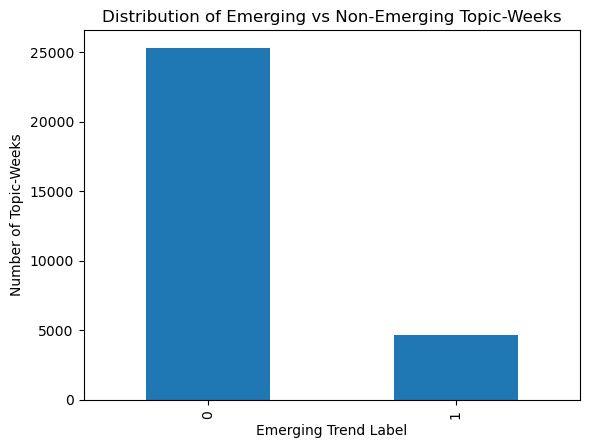

In [58]:
model_df["emerging_trend"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Emerging vs Non-Emerging Topic-Weeks")
plt.xlabel("Emerging Trend Label")
plt.ylabel("Number of Topic-Weeks")
plt.show()

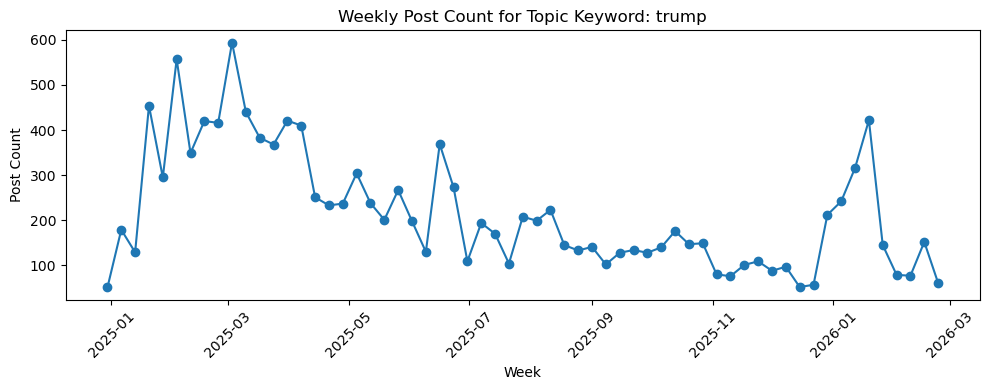

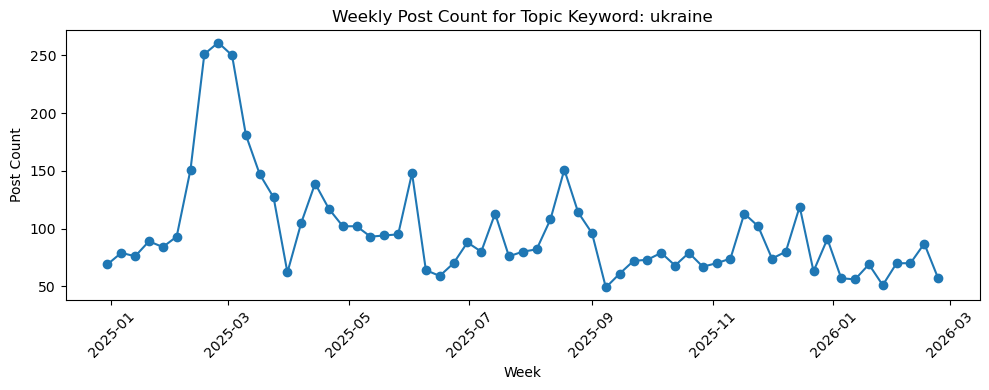

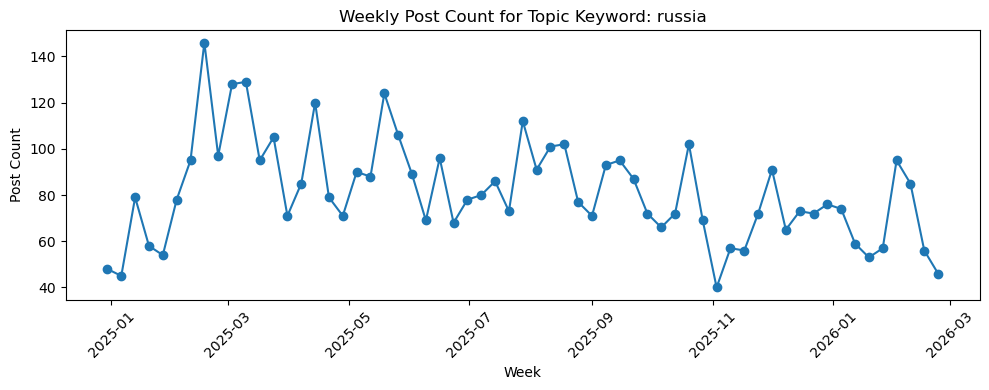

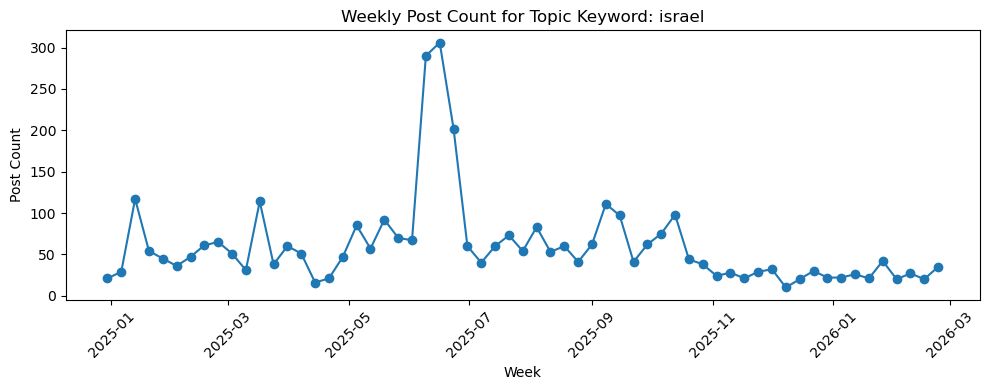

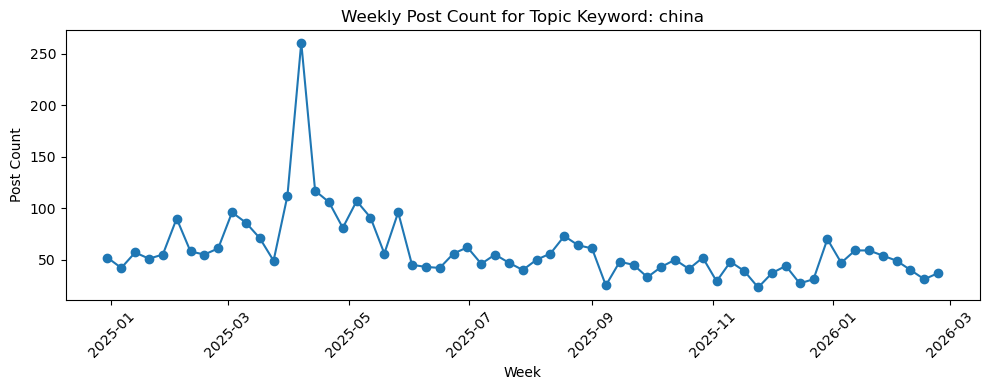

In [59]:
# Show example topic trajectories for the most frequent keywords.
example_topics = [topic for topic, count in keyword_counter.most_common(5)]

for topic in example_topics:
    subset = topic_week[topic_week["topic_keyword"] == topic]
    plt.figure(figsize=(10, 4))
    plt.plot(subset["week"], subset["post_count"], marker="o")
    plt.title(f"Weekly Post Count for Topic Keyword: {topic}")
    plt.xlabel("Week")
    plt.ylabel("Post Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Time-Based Train/Test Split

Because the project predicts future topic emergence, the train/test split must preserve chronological order.

The topic vocabulary is constructed using training-period data only. The final test period is therefore not used when deciding which keywords are retained as topic representations.

The training and testing observations are also separated according to the week used to construct the target label. Since an emerging-trend label depends on the following week's activity, the boundary observation immediately before the test period is excluded. This prevents activity from the first test week from being used to create a training label.

The model is therefore trained entirely using information available before the test period and evaluated on later unseen weeks.

In [61]:
features = [
    "topic_keyword",
    "post_count", "score_sum", "score_mean",
    "comments_sum", "comments_mean",
    "upvote_mean", "unique_authors",
    "title_length_mean", "word_count_mean",
    "prev_post_count", "growth_post_count",
    "prev_score_sum", "growth_score_sum",
    "prev_comments_sum", "growth_comments_sum",
    "prev_unique_authors", "growth_unique_authors"
]

target = "emerging_trend"

# Record which future week provides the target label
model_df["target_week"] = (
    model_df["week"] + pd.Timedelta(weeks=1)
)

# Training rows must have both their observation and target before the test period
train_mask = model_df["target_week"] < cutoff_week

# Testing starts at the chronological cutoff
test_mask = model_df["week"] >= cutoff_week

# The boundary week is excluded because its target depends on the first test week
boundary_mask = ~(train_mask | test_mask)

X_train = model_df.loc[train_mask, features]
y_train = model_df.loc[train_mask, target]

X_test = model_df.loc[test_mask, features]
y_test = model_df.loc[test_mask, target]

print("Cutoff week:", cutoff_week)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Boundary rows excluded:", boundary_mask.sum())

print("\nTraining emerging rate:", y_train.mean())
print("Testing emerging rate:", y_test.mean())

print("\nLatest observation week used for training:")
print(model_df.loc[train_mask, "week"].max())

print("\nLatest target week used for training:")
print(model_df.loc[train_mask, "target_week"].max())

print("\nEarliest observation week used for testing:")
print(model_df.loc[test_mask, "week"].min())

print("\nExcluded boundary week(s):")
print(
    sorted(
        model_df.loc[
            boundary_mask,
            "week"
        ].unique()
    )
)

Cutoff week: 2025-12-01 00:00:00

Training rows: 23500
Testing rows: 6000
Boundary rows excluded: 500

Training emerging rate: 0.162
Testing emerging rate: 0.13783333333333334

Latest observation week used for training:
2025-11-17 00:00:00

Latest target week used for training:
2025-11-24 00:00:00

Earliest observation week used for testing:
2025-12-01 00:00:00

Excluded boundary week(s):
[Timestamp('2025-11-24 00:00:00')]


In [62]:
# Check whether topic keywords overlap between training and testing periods
train_topics = set(X_train["topic_keyword"].unique())
test_topics = set(X_test["topic_keyword"].unique())

overlapping_topics = train_topics.intersection(test_topics)
train_only_topics = train_topics - test_topics
test_only_topics = test_topics - train_topics

topic_overlap_summary = pd.DataFrame([
    {"Metric": "Training topics", "Value": len(train_topics)},
    {"Metric": "Testing topics", "Value": len(test_topics)},
    {"Metric": "Overlapping topics", "Value": len(overlapping_topics)},
    {"Metric": "Train-only topics", "Value": len(train_only_topics)},
    {"Metric": "Test-only topics", "Value": len(test_only_topics)},
    {"Metric": "Percentage of test topics seen in training", "Value": round(len(overlapping_topics) / len(test_topics) * 100, 2)}
])

topic_overlap_summary

,Metric,Value
0,Training topics,500.0
1,Testing topics,500.0
2,Overlapping topics,500.0
3,Train-only topics,0.0
4,Test-only topics,0.0
5,Percentage of test topics seen in training,100.0


## 11. Baseline Models

Two simple baseline models are used:

1. **Logistic Regression** — a simple and interpretable classification model.
2. **Decision Tree** — a non-linear baseline that can capture simple threshold rules.

These are suitable for the preliminary prototype because the aim is to prove feasibility before moving to more advanced models.

In [64]:
numeric_features = [feature for feature in features if feature != "topic_keyword"]
categorical_features = ["topic_keyword"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("topic", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    )
}

results = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results[model_name] = {
        "pipeline": pipeline,
        "predictions": predictions,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0)
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, predictions, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.55      0.69      5173
           1       0.22      0.78      0.34       827

    accuracy                           0.58      6000
   macro avg       0.58      0.66      0.52      6000
weighted avg       0.84      0.58      0.65      6000

Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.52      0.66      5173
           1       0.20      0.74      0.31       827

    accuracy                           0.55      6000
   macro avg       0.56      0.63      0.49      6000
weighted avg       0.83      0.55      0.61      6000



## 11.1 Majority Class Baseline
A Dummy Classifier is added as a simple majority-class baseline. This model does not learn patterns from the features. Instead, it always predicts the most common class in the training data.

This baseline is useful because the dataset is imbalanced: most topic-weeks are not labelled as emerging trends. Therefore, a model could achieve high accuracy by always predicting “not emerging”, while still failing to detect any actual emerging trends.

Comparing Logistic Regression and Decision Tree against this baseline helps evaluate whether the machine learning models are genuinely useful for identifying emerging trends, rather than only appearing accurate because of class imbalance.

In [66]:
# Create a majority-class baseline model.
# This model always predicts the most frequent class from the training data.
dummy_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Train the dummy model
dummy_pipeline.fit(X_train, y_train)

# Make predictions on the test set
dummy_predictions = dummy_pipeline.predict(X_test)

# Store results in the same results dictionary used by the other models
results["Dummy Classifier"] = {
    "pipeline": dummy_pipeline,
    "predictions": dummy_predictions,
    "accuracy": accuracy_score(y_test, dummy_predictions),
    "precision": precision_score(y_test, dummy_predictions, zero_division=0),
    "recall": recall_score(y_test, dummy_predictions, zero_division=0),
    "f1": f1_score(y_test, dummy_predictions, zero_division=0),
}

print("=" * 70)
print("Dummy Classifier")
print("=" * 70)
print(classification_report(y_test, dummy_predictions, zero_division=0))

Dummy Classifier
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      5173
           1       0.00      0.00      0.00       827

    accuracy                           0.86      6000
   macro avg       0.43      0.50      0.46      6000
weighted avg       0.74      0.86      0.80      6000



### 11.1.1 Keyword Baseline Results Summary

The performance of the keyword-based Logistic Regression, Decision Tree and majority-class baseline is summarised below before comparison with the semantic topic representation.

In [68]:
# Summarise the keyword-based baseline results
results_df = pd.DataFrame([
    {
        "model": model_name,
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"]
    }
    for model_name, result in results.items()
])

results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.582500,0.216937,0.777509,0.339224
1,Decision Tree,0.546667,0.196926,0.743652,0.311392
2,Dummy Classifier,0.862167,0.000000,0.000000,0.000000


### 11.2 Keyword vs Semantic Topic Representation Comparison

The original keyword-based topic representation is compared with the TF-IDF, SVD and clustering-based semantic topic representation.

Both approaches use the same temporal, engagement, author and basic text feature definitions and the same trend-emergence rule. This provides a more controlled comparison of whether the alternative topic representation improves predictive performance.

In [70]:
# Label the original keyword-based results
keyword_comparison = results_df.copy()

keyword_comparison.insert(
    0,
    "topic_representation",
    "Keyword"
)

# Label the semantic-topic results
semantic_comparison = (
    semantic_results_df.copy()
)

semantic_comparison.insert(
    0,
    "topic_representation",
    "TF-IDF + SVD Clustering"
)

# Combine both approaches
topic_method_comparison = pd.concat(
    [
        keyword_comparison,
        semantic_comparison
    ],
    ignore_index=True
)

topic_method_comparison

,topic_representation,model,accuracy,precision,recall,f1
0,Keyword,Logistic Regression,0.582500,0.216937,0.777509,0.339224
1,Keyword,Decision Tree,0.546667,0.196926,0.743652,0.311392
2,Keyword,Dummy Classifier,0.862167,0.000000,0.000000,0.000000
3,TF-IDF + SVD Clustering,Logistic Regression,0.590000,0.238487,0.833333,0.370844
4,TF-IDF + SVD Clustering,Decision Tree,0.685833,0.289855,0.804598,0.426180
5,TF-IDF + SVD Clustering,Dummy Classifier,0.855000,0.000000,0.000000,0.000000


In [71]:
results_df = pd.DataFrame([
    {
        "model": model_name,
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"]
    }
    for model_name, result in results.items()
])

results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.582500,0.216937,0.777509,0.339224
1,Decision Tree,0.546667,0.196926,0.743652,0.311392
2,Dummy Classifier,0.862167,0.000000,0.000000,0.000000


## 12. Confusion Matrix

The confusion matrix shows where the model correctly and incorrectly predicts emerging topic-weeks.

For this problem, recall is important because missing an emerging trend may be more costly than producing some false positives. However, precision is also important because too many false alarms would make the model less useful.

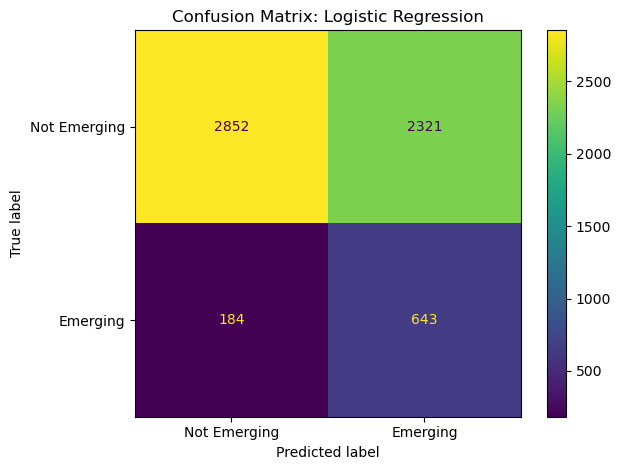

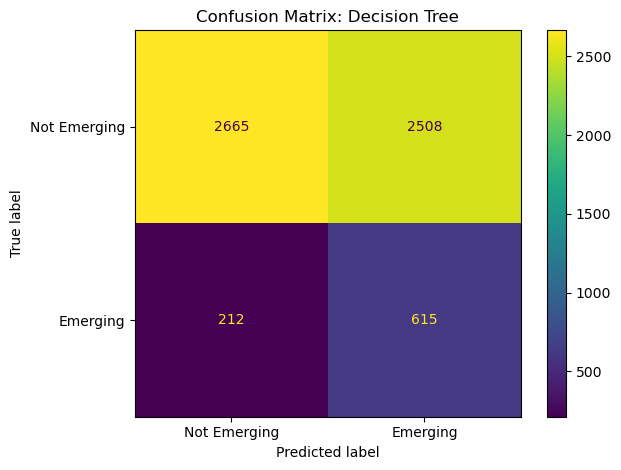

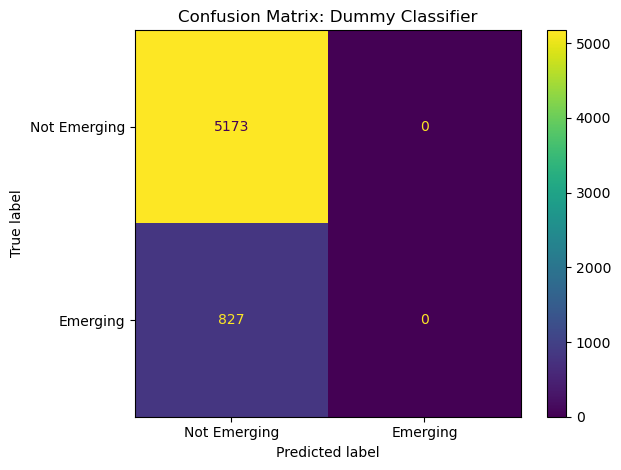

In [73]:
for model_name, result in results.items():
    cm = confusion_matrix(y_test, result["predictions"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Emerging", "Emerging"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(f"figure_confusion_matrix_{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

## 13. Hyperparameter Tuning

The initial Logistic Regression and Decision Tree models used manually selected baseline hyperparameters. To determine whether model performance can be improved, hyperparameter tuning is now performed.

Because this is a temporal prediction problem, the final test period is not used for model selection. Instead, the existing pre-test training period is divided chronologically into an inner training period and a validation period.

Candidate hyperparameter settings are trained using the earlier inner-training weeks and evaluated on the later validation weeks. The F1-score for the emerging class is used as the main selection metric because the dataset is imbalanced and the current models need to balance recall against false-positive predictions.

After the best hyperparameters are selected, the chosen model will be retrained using the full pre-test training period and evaluated once on the later test period.

### 13.1 Chronological Training and Validation Split

The pre-test training period is divided chronologically into an earlier inner-training period and a later validation period. The observation immediately before the validation period is excluded because its target depends on activity within the validation period.

This split is used for hyperparameter tuning and feature-group analysis without using the later chronological evaluation period for model selection.

In [76]:
# Use only the pre-test semantic observations for hyperparameter tuning
semantic_pretest_df = semantic_model_df.loc[
    semantic_train_mask
].copy()

# Find the unique observation weeks available before the final test period
pretest_weeks = sorted(
    semantic_pretest_df["week"].unique()
)

# Use the final 20% of the pre-test weeks as validation
validation_cutoff_week = pretest_weeks[
    int(len(pretest_weeks) * 0.8)
]

# Inner training targets must remain completely before validation
inner_train_mask = (
    semantic_pretest_df["target_week"]
    < validation_cutoff_week
)

# Validation starts at the validation cutoff
validation_mask = (
    semantic_pretest_df["week"]
    >= validation_cutoff_week
)

# Exclude the boundary observation whose target enters validation
inner_boundary_mask = ~(
    inner_train_mask | validation_mask
)

X_inner_train = semantic_pretest_df.loc[
    inner_train_mask,
    semantic_features
]

y_inner_train = semantic_pretest_df.loc[
    inner_train_mask,
    semantic_target
]

X_validation = semantic_pretest_df.loc[
    validation_mask,
    semantic_features
]

y_validation = semantic_pretest_df.loc[
    validation_mask,
    semantic_target
]

print("Validation cutoff week:", validation_cutoff_week)

print("\nInner training rows:", X_inner_train.shape[0])
print("Validation rows:", X_validation.shape[0])
print("Boundary rows excluded:", inner_boundary_mask.sum())

print(
    "\nInner training emerging rate:",
    y_inner_train.mean()
)

print(
    "Validation emerging rate:",
    y_validation.mean()
)

print("\nLatest inner-training observation week:")
print(
    semantic_pretest_df.loc[
        inner_train_mask,
        "week"
    ].max()
)

print("\nLatest inner-training target week:")
print(
    semantic_pretest_df.loc[
        inner_train_mask,
        "target_week"
    ].max()
)

print("\nEarliest validation observation week:")
print(
    semantic_pretest_df.loc[
        validation_mask,
        "week"
    ].min()
)

Validation cutoff week: 2025-09-15 00:00:00

Inner training rows: 3600
Validation rows: 1000
Boundary rows excluded: 100

Inner training emerging rate: 0.1597222222222222
Validation emerging rate: 0.156

Latest inner-training observation week:
2025-09-01 00:00:00

Latest inner-training target week:
2025-09-08 00:00:00

Earliest validation observation week:
2025-09-15 00:00:00


### 13.2 Logistic Regression Hyperparameter Tuning

The baseline Logistic Regression model used manually selected settings, including balanced class weights and the `liblinear` solver.

To improve the model systematically, different values of the regularisation strength `C` and penalty type are evaluated using the chronological validation set.

`C` controls the strength of regularisation. Smaller values apply stronger regularisation, while larger values allow the model to fit the training data more closely.

Both L1 and L2 penalties are tested because they apply different forms of regularisation. The class weight remains set to `balanced` because the emerging-trend class is less frequent than the non-emerging class.

The models are compared primarily using validation F1-score for the emerging class. Precision and recall are also recorded so that the balance between detecting emerging trends and producing false positives can be examined.

The final test set is not used during hyperparameter selection.

In [78]:
# Candidate Logistic Regression hyperparameters
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "regularisation": ["l1", "l2"]
}

logistic_tuning_results = []

for regularisation in logistic_param_grid["regularisation"]:
    for c_value in logistic_param_grid["C"]:

        # Newer scikit-learn versions use l1_ratio
        if regularisation == "l1":
            l1_ratio_value = 1.0
        else:
            l1_ratio_value = 0.0

        model = LogisticRegression(
            C=c_value,
            l1_ratio=l1_ratio_value,
            solver="liblinear",
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )

        pipeline = Pipeline(
            steps=[
                ("preprocess", clone(semantic_preprocess)),
                ("model", model)
            ]
        )

        # Train using the earlier inner-training period
        pipeline.fit(
            X_inner_train,
            y_inner_train
        )

        # Evaluate on the later validation period
        validation_predictions = pipeline.predict(
            X_validation
        )

        logistic_tuning_results.append({
            "C": c_value,
            "regularisation": regularisation,
            "accuracy": accuracy_score(
                y_validation,
                validation_predictions
            ),
            "precision": precision_score(
                y_validation,
                validation_predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_validation,
                validation_predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_validation,
                validation_predictions,
                zero_division=0
            )
        })

logistic_tuning_df = pd.DataFrame(
    logistic_tuning_results
)

# Rank configurations using validation F1-score
logistic_tuning_df = (
    logistic_tuning_df
    .sort_values(
        ["f1", "precision", "recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

logistic_tuning_df

,C,regularisation,accuracy,precision,recall,f1
0,1.00,l1,0.537,0.242881,0.929487,0.385126
1,1.00,l2,0.536,0.240741,0.916667,0.381333
2,10.00,l1,0.523,0.236453,0.923077,0.376471
3,10.00,l2,0.523,0.235585,0.916667,0.374836
4,0.10,l1,0.489,0.231467,0.980769,0.374541
5,100.00,l1,0.522,0.235197,0.916667,0.374346
6,100.00,l2,0.522,0.235197,0.916667,0.374346
7,0.10,l2,0.506,0.230032,0.923077,0.368286
8,0.01,l2,0.465,0.223358,0.980769,0.363853
9,0.01,l1,0.399,0.204515,0.987179,0.338834


In [79]:
# Select the configuration with the highest validation F1-score
best_logistic_row = logistic_tuning_df.iloc[0]

best_logistic_params = {
    "C": float(best_logistic_row["C"]),
    "regularisation": best_logistic_row["regularisation"]
}

print("Best Logistic Regression parameters:")
print(best_logistic_params)

print("\nBest validation performance:")
print(
    best_logistic_row[
        [
            "accuracy",
            "precision",
            "recall",
            "f1"
        ]
    ]
)

Best Logistic Regression parameters:
{'C': 1.0, 'regularisation': 'l1'}

Best validation performance:
accuracy        0.537
precision    0.242881
recall       0.929487
f1           0.385126
Name: 0, dtype: object


### 13.3 Decision Tree Hyperparameter Tuning

The baseline Decision Tree used a maximum depth of 6 together with balanced class weights. However, the choice of tree depth and other structural parameters can strongly affect model performance.

A tree that is too shallow may underfit the data, while a very deep tree may learn noise from the training period and generalise poorly to later weeks.

The following hyperparameters are therefore evaluated:

- `max_depth`: controls the maximum depth of the tree
- `min_samples_split`: controls the minimum number of observations required to split a node
- `min_samples_leaf`: controls the minimum number of observations required in a leaf
- `criterion`: controls how the quality of a split is measured

The class weight remains set to `balanced` because emerging topic-weeks are less common than non-emerging topic-weeks.

Each candidate model is trained on the chronological inner-training period and evaluated on the later validation period. The validation F1-score for the emerging class is used as the main criterion for selecting the final hyperparameters.

In [81]:
# Candidate Decision Tree hyperparameters
tree_param_grid = {
    "max_depth": [3, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

tree_tuning_results = []

for criterion in tree_param_grid["criterion"]:
    for max_depth in tree_param_grid["max_depth"]:
        for min_samples_split in tree_param_grid["min_samples_split"]:
            for min_samples_leaf in tree_param_grid["min_samples_leaf"]:

                model = DecisionTreeClassifier(
                    criterion=criterion,
                    max_depth=max_depth,
                    min_samples_split=min_samples_split,
                    min_samples_leaf=min_samples_leaf,
                    class_weight="balanced",
                    random_state=42
                )

                pipeline = Pipeline(
                    steps=[
                        ("preprocess", clone(semantic_preprocess)),
                        ("model", model)
                    ]
                )

                # Train using the earlier inner-training period
                pipeline.fit(
                    X_inner_train,
                    y_inner_train
                )

                # Evaluate using the later validation period
                validation_predictions = pipeline.predict(
                    X_validation
                )

                tree_tuning_results.append({
                    "criterion": criterion,
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                    "min_samples_leaf": min_samples_leaf,
                    "accuracy": accuracy_score(
                        y_validation,
                        validation_predictions
                    ),
                    "precision": precision_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    ),
                    "recall": recall_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    ),
                    "f1": f1_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    )
                })

tree_tuning_df = pd.DataFrame(
    tree_tuning_results
)

# Rank configurations using validation F1-score
tree_tuning_df = (
    tree_tuning_df
    .sort_values(
        ["f1", "precision", "recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Number of Decision Tree configurations tested:")
print(len(tree_tuning_df))

tree_tuning_df.head(20)

Number of Decision Tree configurations tested:
192


,criterion,max_depth,min_samples_split,min_samples_leaf,accuracy,precision,recall,f1
0,entropy,5.0,2,20,0.665,0.300668,0.865385,0.446281
1,entropy,5.0,5,20,0.665,0.300668,0.865385,0.446281
2,entropy,5.0,10,20,0.665,0.300668,0.865385,0.446281
3,entropy,5.0,20,20,0.665,0.300668,0.865385,0.446281
4,entropy,3.0,2,1,0.637,0.284823,0.878205,0.430141
5,entropy,3.0,2,5,0.637,0.284823,0.878205,0.430141
6,entropy,3.0,2,10,0.637,0.284823,0.878205,0.430141
7,entropy,3.0,2,20,0.637,0.284823,0.878205,0.430141
8,entropy,3.0,5,1,0.637,0.284823,0.878205,0.430141
9,entropy,3.0,5,5,0.637,0.284823,0.878205,0.430141


In [82]:
# Select the Decision Tree configuration with the highest validation F1-score
best_tree_row = tree_tuning_df.iloc[0]

best_tree_params = {
    "criterion": best_tree_row["criterion"],
    "max_depth": best_tree_row["max_depth"],
    "min_samples_split": int(
        best_tree_row["min_samples_split"]
    ),
    "min_samples_leaf": int(
        best_tree_row["min_samples_leaf"]
    )
}

print("Best Decision Tree parameters:")
print(best_tree_params)

print("\nBest validation performance:")
print(
    best_tree_row[
        [
            "accuracy",
            "precision",
            "recall",
            "f1"
        ]
    ]
)

Best Decision Tree parameters:
{'criterion': 'entropy', 'max_depth': np.float64(5.0), 'min_samples_split': 2, 'min_samples_leaf': 20}

Best validation performance:
accuracy        0.665
precision    0.300668
recall       0.865385
f1           0.446281
Name: 0, dtype: object


### 13.4 Hyperparameter Tuning Summary

Hyperparameter tuning was performed using a chronological inner-training and validation split. The final test period was not used during model selection.

For Logistic Regression, different regularisation strengths and L1/L2 regularisation settings were evaluated. The best validation configuration used a regularisation strength of `C = 1.0` with L1 regularisation.

For the Decision Tree, different splitting criteria, maximum tree depths, minimum split sizes and minimum leaf sizes were evaluated. The best validation configuration used the entropy criterion, a maximum depth of 5, a minimum split size of 2 and a minimum leaf size of 20.

The models were selected primarily according to F1-score for the emerging-trend class because the target variable is imbalanced. Precision and recall were also considered when interpreting the results.

The chronological test period is not used during hyperparameter tuning or feature ablation. Earlier baseline models were evaluated on this period, so it is treated as a held-out chronological evaluation period rather than a completely untouched test set. Additional candidate models and feature configurations will first be evaluated using the same validation period before final model evaluation.

In [84]:
# Store the best tuned-model validation results
tuning_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "best_parameters": "C=1.0, L1 regularisation",
        "validation_accuracy": float(
            best_logistic_row["accuracy"]
        ),
        "validation_precision": float(
            best_logistic_row["precision"]
        ),
        "validation_recall": float(
            best_logistic_row["recall"]
        ),
        "validation_f1": float(
            best_logistic_row["f1"]
        )
    },
    {
        "model": "Decision Tree",
        "best_parameters": (
            "criterion=entropy, max_depth=5, "
            "min_samples_split=2, min_samples_leaf=20"
        ),
        "validation_accuracy": float(
            best_tree_row["accuracy"]
        ),
        "validation_precision": float(
            best_tree_row["precision"]
        ),
        "validation_recall": float(
            best_tree_row["recall"]
        ),
        "validation_f1": float(
            best_tree_row["f1"]
        )
    }
])

tuning_summary

,model,best_parameters,validation_accuracy,validation_precision,validation_recall,validation_f1
0,Logistic Regression,"C=1.0, L1 regularisation",0.537,0.242881,0.929487,0.385126
1,Decision Tree,"criterion=entropy, max_depth=5, min_samples_sp...",0.665,0.300668,0.865385,0.446281


## 14. Stronger Model Comparison

The initial modelling stage used Logistic Regression and a single Decision Tree as interpretable baseline classifiers. To investigate whether a more powerful non-linear model can improve prediction, a Random Forest classifier is added.

Random Forest combines predictions from multiple decision trees. Each tree is trained using a different sample of the data and a subset of available features. Combining many trees can reduce the instability and overfitting associated with a single Decision Tree.

The Random Forest is tuned using the same chronological inner-training and validation periods used for the previous models. The later chronological evaluation period is not used during Random Forest hyperparameter tuning.

The main selection metric remains F1-score for the emerging-trend class.

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
# Candidate Random Forest hyperparameters
random_forest_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.5]
}

random_forest_tuning_results = []

for n_estimators in random_forest_param_grid["n_estimators"]:
    for max_depth in random_forest_param_grid["max_depth"]:
        for min_samples_leaf in random_forest_param_grid["min_samples_leaf"]:
            for max_features in random_forest_param_grid["max_features"]:

                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1
                )

                pipeline = Pipeline(
                    steps=[
                        ("preprocess", clone(semantic_preprocess)),
                        ("model", model)
                    ]
                )

                # Train on the chronological inner-training period
                pipeline.fit(
                    X_inner_train,
                    y_inner_train
                )

                # Evaluate on the later validation period
                validation_predictions = pipeline.predict(
                    X_validation
                )

                random_forest_tuning_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "accuracy": accuracy_score(
                        y_validation,
                        validation_predictions
                    ),
                    "precision": precision_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    ),
                    "recall": recall_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    ),
                    "f1": f1_score(
                        y_validation,
                        validation_predictions,
                        zero_division=0
                    )
                })

random_forest_tuning_df = pd.DataFrame(
    random_forest_tuning_results
)

# Rank the configurations using validation F1-score
random_forest_tuning_df = (
    random_forest_tuning_df
    .sort_values(
        ["f1", "precision", "recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("Number of Random Forest configurations tested:")
print(len(random_forest_tuning_df))

random_forest_tuning_df.head(20)

Number of Random Forest configurations tested:
36


,n_estimators,max_depth,min_samples_leaf,max_features,accuracy,precision,recall,f1
0,200,NaN,5,0.5,0.697,0.312020,0.782051,0.446069
1,100,10.0,5,0.5,0.677,0.304450,0.833333,0.445969
2,100,NaN,5,0.5,0.699,0.312661,0.775641,0.445672
3,200,10.0,5,0.5,0.677,0.303529,0.826923,0.444062
4,200,NaN,10,0.5,0.666,0.298643,0.846154,0.441472
5,100,NaN,10,0.5,0.663,0.295711,0.839744,0.437396
6,200,10.0,10,0.5,0.655,0.292308,0.852564,0.435352
7,100,10.0,10,0.5,0.649,0.287582,0.846154,0.429268
8,100,5.0,5,0.5,0.616,0.277344,0.910256,0.425150
9,100,NaN,5,sqrt,0.642,0.282328,0.839744,0.422581


In [88]:
# Select the Random Forest configuration with the highest validation F1-score
best_rf_row = random_forest_tuning_df.iloc[0]

best_rf_max_depth = best_rf_row["max_depth"]

# Convert numeric depth values cleanly while preserving None
if pd.notna(best_rf_max_depth):
    best_rf_max_depth = int(best_rf_max_depth)
else:
    best_rf_max_depth = None

best_rf_params = {
    "n_estimators": int(
        best_rf_row["n_estimators"]
    ),
    "max_depth": best_rf_max_depth,
    "min_samples_leaf": int(
        best_rf_row["min_samples_leaf"]
    ),
    "max_features": best_rf_row["max_features"]
}

print("Best Random Forest parameters:")
print(best_rf_params)

print("\nBest validation performance:")
print(
    best_rf_row[
        [
            "accuracy",
            "precision",
            "recall",
            "f1"
        ]
    ]
)

Best Random Forest parameters:
{'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 0.5}

Best validation performance:
accuracy        0.697
precision     0.31202
recall       0.782051
f1           0.446069
Name: 0, dtype: object


## 15. Feature Group and Ablation Analysis

The project aims to investigate the predictive value of three main types of information: temporal activity, engagement signals and text-based topic information.

Model performance using all features does not show how much each feature group contributes. A feature-group analysis is therefore performed using the chronological inner-training and validation periods.

The tuned Decision Tree is kept fixed throughout this analysis. This prevents differences in model hyperparameters from affecting the comparison.

Two complementary experiments are performed:

1. **Feature-group-only analysis** – each feature group is used independently to examine how much predictive information it contains on its own.
2. **Ablation analysis** – one feature group is removed from the complete feature set at a time to examine how model performance changes.

The later chronological evaluation period is not used during the feature-group or ablation experiments. These experiments are used only to understand the feature groups and finalise the modelling configuration before final evaluation.

In [90]:
# Temporal activity features
temporal_features = [
    "post_count",
    "prev_post_count",
    "growth_post_count"
]

# Engagement and participation features
engagement_features = [
    "score_sum",
    "score_mean",
    "comments_sum",
    "comments_mean",
    "upvote_mean",
    "unique_authors",
    "prev_score_sum",
    "growth_score_sum",
    "prev_comments_sum",
    "growth_comments_sum",
    "prev_unique_authors",
    "growth_unique_authors"
]

# Text and semantic topic features
text_topic_features = [
    "semantic_topic_id",
    "title_length_mean",
    "word_count_mean"
]

print("Temporal features:", len(temporal_features))
print("Engagement features:", len(engagement_features))
print("Text/topic features:", len(text_topic_features))

print(
    "Total features:",
    len(
        temporal_features
        + engagement_features
        + text_topic_features
    )
)

Temporal features: 3
Engagement features: 12
Text/topic features: 3
Total features: 18


In [91]:
#Create preprocessing steps for a selected subset of features
def create_feature_preprocessor(selected_features):

    selected_categorical = [
        feature
        for feature in selected_features
        if feature == "semantic_topic_id"
    ]

    selected_numeric = [
        feature
        for feature in selected_features
        if feature != "semantic_topic_id"
    ]

    transformers = []

    if selected_numeric:
        transformers.append(
            (
                "num",
                StandardScaler(),
                selected_numeric
            )
        )

    if selected_categorical:
        transformers.append(
            (
                "topic",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                selected_categorical
            )
        )

    return ColumnTransformer(
        transformers=transformers
    )

In [92]:
feature_group_sets = {
    "Temporal only": temporal_features,
    "Engagement only": engagement_features,
    "Text/topic only": text_topic_features,
    "All features": (
        temporal_features
        + engagement_features
        + text_topic_features
    )
}

feature_group_results = []

for group_name, selected_features in feature_group_sets.items():

    preprocess = create_feature_preprocessor(
        selected_features
    )

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_inner_train[selected_features],
        y_inner_train
    )

    predictions = pipeline.predict(
        X_validation[selected_features]
    )

    feature_group_results.append({
        "feature_group": group_name,
        "number_of_features": len(
            selected_features
        ),
        "accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            predictions,
            zero_division=0
        )
    })

feature_group_results_df = pd.DataFrame(
    feature_group_results
)

feature_group_results_df = (
    feature_group_results_df
    .sort_values(
        "f1",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_group_results_df

,feature_group,number_of_features,accuracy,precision,recall,f1
0,All features,18,0.665,0.300668,0.865385,0.446281
1,Temporal only,3,0.615,0.275049,0.897436,0.421053
2,Engagement only,12,0.556,0.247368,0.903846,0.388430
3,Text/topic only,3,0.722,0.239316,0.358974,0.287179


In [93]:
all_analysis_features = (
    temporal_features
    + engagement_features
    + text_topic_features
)

ablation_feature_sets = {
    "All features": all_analysis_features,

    "Without temporal": (
        engagement_features
        + text_topic_features
    ),

    "Without engagement": (
        temporal_features
        + text_topic_features
    ),

    "Without text/topic": (
        temporal_features
        + engagement_features
    )
}

ablation_results = []

for experiment_name, selected_features in ablation_feature_sets.items():

    preprocess = create_feature_preprocessor(
        selected_features
    )

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )

    pipeline.fit(
        X_inner_train[selected_features],
        y_inner_train
    )

    predictions = pipeline.predict(
        X_validation[selected_features]
    )

    ablation_results.append({
        "experiment": experiment_name,
        "number_of_features": len(
            selected_features
        ),
        "accuracy": accuracy_score(
            y_validation,
            predictions
        ),
        "precision": precision_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_validation,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_validation,
            predictions,
            zero_division=0
        )
    })

ablation_results_df = pd.DataFrame(
    ablation_results
)

ablation_results_df

,experiment,number_of_features,accuracy,precision,recall,f1
0,All features,18,0.665,0.300668,0.865385,0.446281
1,Without temporal,15,0.582,0.257407,0.891026,0.399425
2,Without engagement,6,0.629,0.281059,0.884615,0.426584
3,Without text/topic,15,0.645,0.287846,0.865385,0.432000


In [94]:
# Get validation F1-score when all features are present
all_features_f1 = ablation_results_df.loc[
    ablation_results_df["experiment"] == "All features",
    "f1"
].iloc[0]

ablation_results_df["f1_change_vs_all"] = (
    ablation_results_df["f1"]
    - all_features_f1
)

ablation_results_df

,experiment,number_of_features,accuracy,precision,recall,f1,f1_change_vs_all
0,All features,18,0.665,0.300668,0.865385,0.446281,0.000000
1,Without temporal,15,0.582,0.257407,0.891026,0.399425,-0.046856
2,Without engagement,6,0.629,0.281059,0.884615,0.426584,-0.019697
3,Without text/topic,15,0.645,0.287846,0.865385,0.432000,-0.014281


## 16. Final Model Evaluation

All model-development decisions have now been completed using the chronological training and validation periods.

The feature-group analysis showed that the complete feature set achieved the strongest validation F1-score. Temporal activity provided the largest individual contribution, while engagement and semantic/text features also provided additional predictive information.

The final modelling configuration is therefore fixed before the final evaluation of the held-out chronological evaluation period.

The selected Logistic Regression, Decision Tree and Random Forest models are retrained using the complete pre-test training dataset. Their performance is then evaluated on the held-out chronological test period after completing hyperparameter tuning and feature-group analysis using only the earlier training and validation periods.

The Dummy Classifier is retained as a majority-class baseline.

No further hyperparameter or feature selection decisions are made using the final test results.

In [96]:
# Convert the selected Logistic Regression regularisation setting
final_logistic_l1_ratio = 1.0

final_models = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        l1_ratio=final_logistic_l1_ratio,
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        max_features=0.5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

final_results = {}

for model_name, model in final_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocess", clone(semantic_preprocess)),
            ("model", model)
        ]
    )

    # Retrain using the complete pre-test training period
    pipeline.fit(
        X_train_semantic,
        y_train_semantic
    )

    # Evaluate on the held-out chronological evaluation period
    test_predictions = pipeline.predict(
        X_test_semantic
    )

    final_results[model_name] = {
        "pipeline": pipeline,
        "predictions": test_predictions,
        "accuracy": accuracy_score(
            y_test_semantic,
            test_predictions
        ),
        "precision": precision_score(
            y_test_semantic,
            test_predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_semantic,
            test_predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_semantic,
            test_predictions,
            zero_division=0
        )
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test_semantic,
            test_predictions,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.54      0.69      1026
           1       0.24      0.84      0.37       174

    accuracy                           0.59      1200
   macro avg       0.60      0.69      0.53      1200
weighted avg       0.85      0.59      0.65      1200

Decision Tree
              precision    recall  f1-score   support

           0       0.96      0.65      0.78      1026
           1       0.29      0.83      0.43       174

    accuracy                           0.68      1200
   macro avg       0.62      0.74      0.60      1200
weighted avg       0.86      0.68      0.73      1200

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1026
           1       0.33      0.70      0.45       174

    accuracy                           0.75      1200
   macro avg       0.63      0.73      0.64      1200
weighted avg       0.85   

In [97]:
# Majority-class baseline for the final test evaluation
final_dummy_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(semantic_preprocess)),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

final_dummy_pipeline.fit(
    X_train_semantic,
    y_train_semantic
)

final_dummy_predictions = (
    final_dummy_pipeline.predict(
        X_test_semantic
    )
)

final_results["Dummy Classifier"] = {
    "pipeline": final_dummy_pipeline,
    "predictions": final_dummy_predictions,
    "accuracy": accuracy_score(
        y_test_semantic,
        final_dummy_predictions
    ),
    "precision": precision_score(
        y_test_semantic,
        final_dummy_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test_semantic,
        final_dummy_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test_semantic,
        final_dummy_predictions,
        zero_division=0
    )
}

In [98]:
final_results_df = pd.DataFrame([
    {
        "model": model_name,
        "accuracy": result["accuracy"],
        "precision": result["precision"],
        "recall": result["recall"],
        "f1": result["f1"]
    }
    for model_name, result
    in final_results.items()
])

final_results_df = (
    final_results_df
    .sort_values(
        "f1",
        ascending=False
    )
    .reset_index(drop=True)
)

final_results_df

,model,accuracy,precision,recall,f1
0,Random Forest,0.752500,0.331507,0.695402,0.448980
1,Decision Tree,0.679167,0.289421,0.833333,0.429630
2,Logistic Regression,0.588333,0.239414,0.844828,0.373096
3,Dummy Classifier,0.855000,0.000000,0.000000,0.000000


In [99]:
validation_model_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "validation_precision": float(
            best_logistic_row["precision"]
        ),
        "validation_recall": float(
            best_logistic_row["recall"]
        ),
        "validation_f1": float(
            best_logistic_row["f1"]
        )
    },
    {
        "model": "Decision Tree",
        "validation_precision": float(
            best_tree_row["precision"]
        ),
        "validation_recall": float(
            best_tree_row["recall"]
        ),
        "validation_f1": float(
            best_tree_row["f1"]
        )
    },
    {
        "model": "Random Forest",
        "validation_precision": float(
            best_rf_row["precision"]
        ),
        "validation_recall": float(
            best_rf_row["recall"]
        ),
        "validation_f1": float(
            best_rf_row["f1"]
        )
    }
])

test_model_results = (
    final_results_df[
        final_results_df["model"] != "Dummy Classifier"
    ][
        ["model", "precision", "recall", "f1"]
    ]
    .rename(
        columns={
            "precision": "test_precision",
            "recall": "test_recall",
            "f1": "test_f1"
        }
    )
)

validation_test_comparison = (
    validation_model_results
    .merge(
        test_model_results,
        on="model"
    )
)

validation_test_comparison["f1_change"] = (
    validation_test_comparison["test_f1"]
    - validation_test_comparison["validation_f1"]
)

validation_test_comparison

,model,validation_precision,validation_recall,validation_f1,test_precision,test_recall,test_f1,f1_change
0,Logistic Regression,0.242881,0.929487,0.385126,0.239414,0.844828,0.373096,-0.012030
1,Decision Tree,0.300668,0.865385,0.446281,0.289421,0.833333,0.429630,-0.016651
2,Random Forest,0.312020,0.782051,0.446069,0.331507,0.695402,0.448980,0.002910


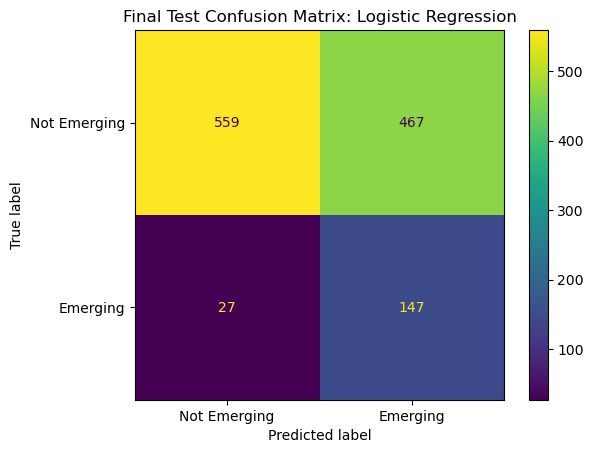

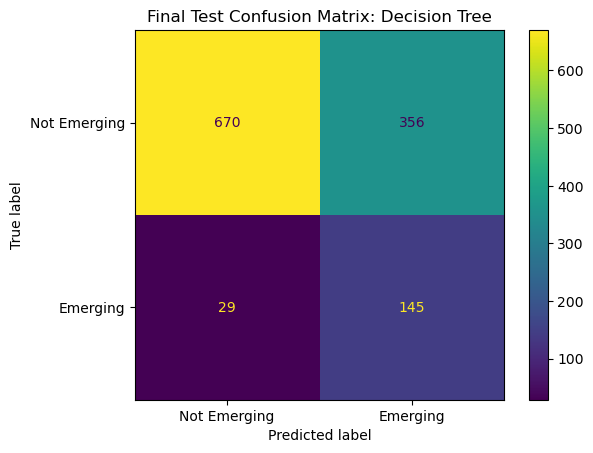

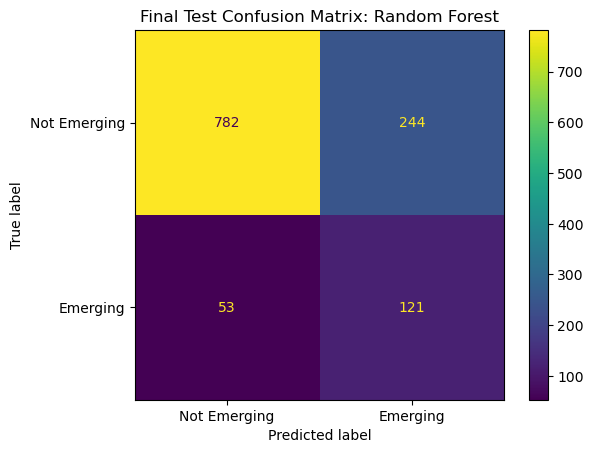

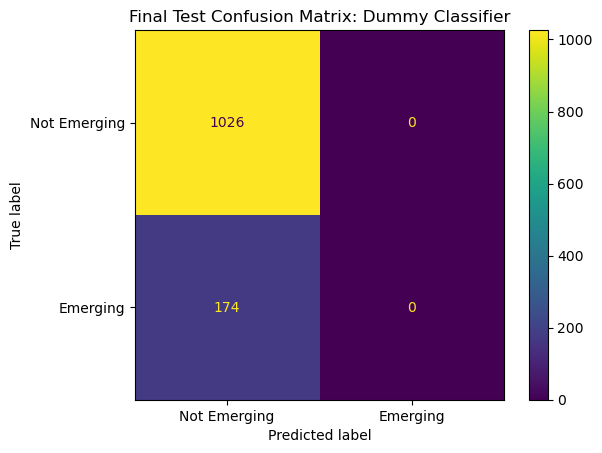

In [100]:
for model_name, result in final_results.items():

    cm = confusion_matrix(
        y_test_semantic,
        result["predictions"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Not Emerging",
            "Emerging"
        ]
    )

    disp.plot(
        values_format="d"
    )

    plt.title(
        f"Final Test Confusion Matrix: {model_name}"
    )

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"final_confusion_matrix_{safe_name}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

### 16.6 Precision-Recall Evaluation

Precision-recall analysis is used as an additional evaluation because emerging topic-weeks form the minority class.

A precision-recall curve shows the trade-off between precision and recall across different classification thresholds rather than evaluating only the default threshold.

Average Precision (AP) summarises the precision-recall curve as a single value. Higher values indicate that the model is better able to rank actual emerging topic-weeks above non-emerging topic-weeks.

The positive-class prevalence is also shown as a reference baseline. The curves are used only for evaluation and no classification threshold is changed based on the test-period results.

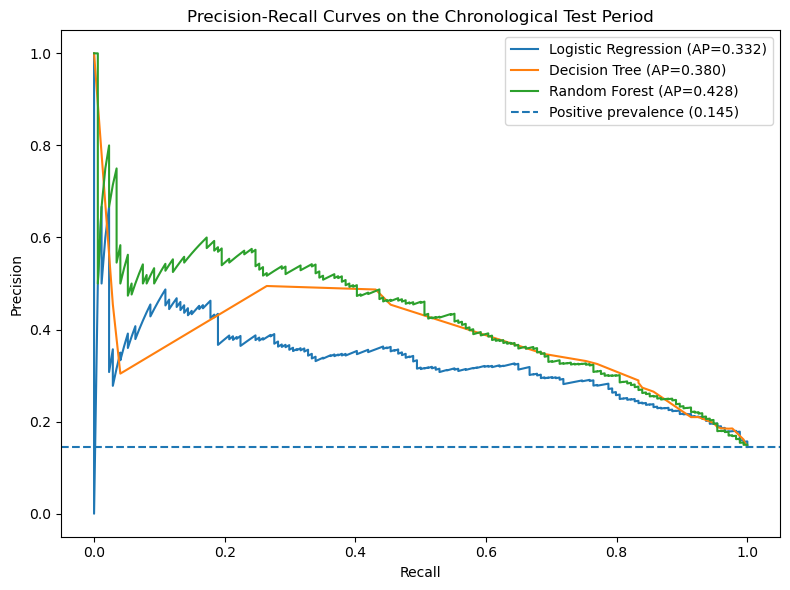

,model,average_precision
0,Random Forest,0.428166
1,Decision Tree,0.379715
2,Logistic Regression,0.332039


In [102]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Store precision-recall evaluation results
pr_results = []

plt.figure(figsize=(8, 6))

for model_name, result in final_results.items():

    # Skip the majority-class baseline for probability ranking analysis
    if model_name == "Dummy Classifier":
        continue

    pipeline = result["pipeline"]

    # Get probability estimates for the emerging class
    positive_probabilities = pipeline.predict_proba(
        X_test_semantic
    )[:, 1]

    precision_values, recall_values, _ = precision_recall_curve(
        y_test_semantic,
        positive_probabilities
    )

    average_precision = average_precision_score(
        y_test_semantic,
        positive_probabilities
    )

    pr_results.append({
        "model": model_name,
        "average_precision": average_precision
    })

    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP={average_precision:.3f})"
    )

# Positive-class prevalence provides a simple reference baseline
positive_prevalence = y_test_semantic.mean()

plt.axhline(
    y=positive_prevalence,
    linestyle="--",
    label=f"Positive prevalence ({positive_prevalence:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves on the Chronological Test Period")
plt.legend()
plt.tight_layout()

plt.savefig(
    "final_precision_recall_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

pr_results_df = pd.DataFrame(
    pr_results
).sort_values(
    "average_precision",
    ascending=False
).reset_index(drop=True)

pr_results_df

### 16.7 Final Error Analysis

The confusion matrices are summarised numerically to examine the types of errors made by each model.

False positives represent topic-weeks that were predicted to become emerging but did not meet the emergence definition in the following week.

False negatives represent genuinely emerging topic-weeks that the model failed to identify.

For an early trend-detection system, false negatives are particularly important because they represent emerging topics that would be missed. However, a very large number of false positives would also reduce the practical usefulness of the system.

In [104]:
final_error_analysis = []

for model_name, result in final_results.items():

    tn, fp, fn, tp = confusion_matrix(
        y_test_semantic,
        result["predictions"]
    ).ravel()

    final_error_analysis.append({
        "model": model_name,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
        "predicted_emerging": fp + tp
    })

final_error_analysis_df = pd.DataFrame(
    final_error_analysis
)

final_error_analysis_df

,model,true_negative,false_positive,false_negative,true_positive,predicted_emerging
0,Logistic Regression,559,467,27,147,614
1,Decision Tree,670,356,29,145,501
2,Random Forest,782,244,53,121,365
3,Dummy Classifier,1026,0,174,0,0


## 17. Final Project Reflection and Limitations

The final implementation demonstrates an end-to-end predictive modelling pipeline for social media trend emergence using Reddit world news data.

The project progressed from a simple keyword-based prototype to a more structured semantic topic representation. The original keyword method provided an interpretable baseline but could produce overlapping and noisy topics because individual words do not always represent complete discussions. An alternative approach using TF-IDF, dimensionality reduction with Truncated SVD, and MiniBatch K-Means clustering was therefore implemented.

The semantic topic representation produced stronger baseline classification results than the original keyword representation. This suggests that grouping posts according to broader textual similarity provides more useful information for trend-emergence prediction than relying only on individual frequent keywords.

Hyperparameter tuning was then performed using a chronological inner-training and validation split. This avoided using the later evaluation period when selecting Logistic Regression, Decision Tree and Random Forest configurations.

The feature-group analysis showed that the complete feature set achieved the strongest validation F1-score. Temporal activity features provided the largest individual predictive contribution. Engagement and participation features also contributed useful information, while text and semantic-topic features provided a smaller but positive contribution when combined with the other feature groups.

On the chronological evaluation period, Random Forest achieved the strongest overall F1-score and Average Precision. Logistic Regression achieved the highest recall, but this came at the cost of substantially more false-positive predictions. The Decision Tree provided an intermediate balance between the two.

These results suggest that early social media trend emergence cannot be represented reliably by a single type of signal. Temporal growth appears to be particularly important, but combining temporal, engagement and semantic information provides stronger predictive performance.

### 17.1 Summary of Main Findings

The main findings from the implementation are:

1. **Semantic topic representation improved prediction.**  
   TF-IDF, SVD and clustering produced stronger Logistic Regression and Decision Tree performance than the original keyword-based topic representation.

2. **Temporal information was the strongest individual feature group.**  
   Temporal features alone achieved a validation F1-score of approximately 0.421. Removing temporal features from the complete model produced the largest reduction in F1-score.

3. **Engagement information provided additional predictive value.**  
   Engagement-related features alone were weaker than temporal features, but removing them from the complete feature set reduced model performance.

4. **Text and semantic topic information contributed additional information.**  
   Text/topic features were the weakest feature group when used independently, but removing them from the complete feature set still reduced F1-score.

5. **The Dummy Classifier demonstrated why accuracy alone was misleading.**  
   Although the majority-class baseline achieved high accuracy, it identified no emerging topic-weeks.

6. **Random Forest provided the strongest overall final performance.**  
   On the chronological evaluation period, Random Forest achieved an F1-score of approximately 0.449 and an Average Precision of approximately 0.428.

7. **Different models produced different precision-recall trade-offs.**  
   Logistic Regression detected the greatest proportion of emerging trends but generated considerably more false positives, while Random Forest produced fewer false alarms at the cost of missing more emerging trends.

### 17.2 Current Limitations

Despite the improvements made during development, several limitations remain.

#### Topic representation

The semantic topic representation is more meaningful than the original keyword approach, but it is still an approximation. TF-IDF primarily represents lexical similarity and may not recognise posts discussing the same event using very different vocabulary. More advanced sentence embeddings could provide stronger semantic representations.

The number of topic clusters was also fixed at 100 for the current implementation. Although inspection showed that the improved clusters were substantially more coherent than the initial clustering attempt, different numbers of clusters may produce different topic structures.

#### Trend-emergence definition

Trend emergence is operationally defined using future post-count growth. A topic-week is considered emerging when its following-week post count is at least twice the current-week post count and the following week contains at least five posts.

This provides a consistent and measurable target, but real social media trends may involve more than posting frequency. Engagement growth, sentiment, user diversity, network diffusion and cross-platform spread could also contribute to whether a topic should be considered a trend.

#### Dataset scope

The project uses Reddit world news data from one subreddit. The findings therefore describe behaviour within this dataset and should not automatically be generalised to all social media platforms or topic domains.

Different platforms such as X, TikTok or YouTube have different user behaviour, recommendation systems and content formats.

#### Comments and network structure

The available comments dataset was not incorporated into the final modelling pipeline. Comment text, reply behaviour and interaction networks could provide additional information about discussion intensity and information diffusion.

Network-based features were also outside the final implementation scope.

#### Model performance

Although the machine learning models detected emerging topic-weeks better than the majority-class baseline, precision remained relatively low. This means that a practical trend-monitoring system based on the current implementation would still generate a substantial number of false-positive alerts.

#### Evaluation design

The project used chronological training, validation and evaluation periods to preserve temporal order. However, the later evaluation period was inspected during an earlier semantic baseline comparison before the final tuning stage. It was not used for hyperparameter tuning or feature-group selection, but this means that it should be described as a held-out chronological evaluation period rather than a completely untouched test set.

Future work could use rolling or walk-forward evaluation across several time periods to provide a stronger estimate of temporal generalisation.

### 17.3 Future Improvements

Several extensions could improve the project beyond the current implementation.

A stronger semantic representation could be investigated using sentence embeddings or transformer-based language models. This could group posts according to meaning even when they use different vocabulary.

The comments dataset could also be incorporated. Comment volume, sentiment, reply activity and user participation may provide early signals that are not visible from post-level information alone.

Network-related features could be introduced to measure how discussion spreads between users or communities. This would make the implementation more closely aligned with research on information diffusion.

The trend-emergence definition could also be extended beyond post-count growth by combining activity growth with engagement and user-diversity thresholds.

Finally, future evaluation could use rolling-window or walk-forward validation over multiple time periods. This would provide stronger evidence about how reliably the model generalises as social media discussions change over time.

## 18. Project Plan Gantt Chart

The following Gantt chart summarises the major stages of the project, from initial scope definition and background research through data preparation, modelling, evaluation and final report preparation.

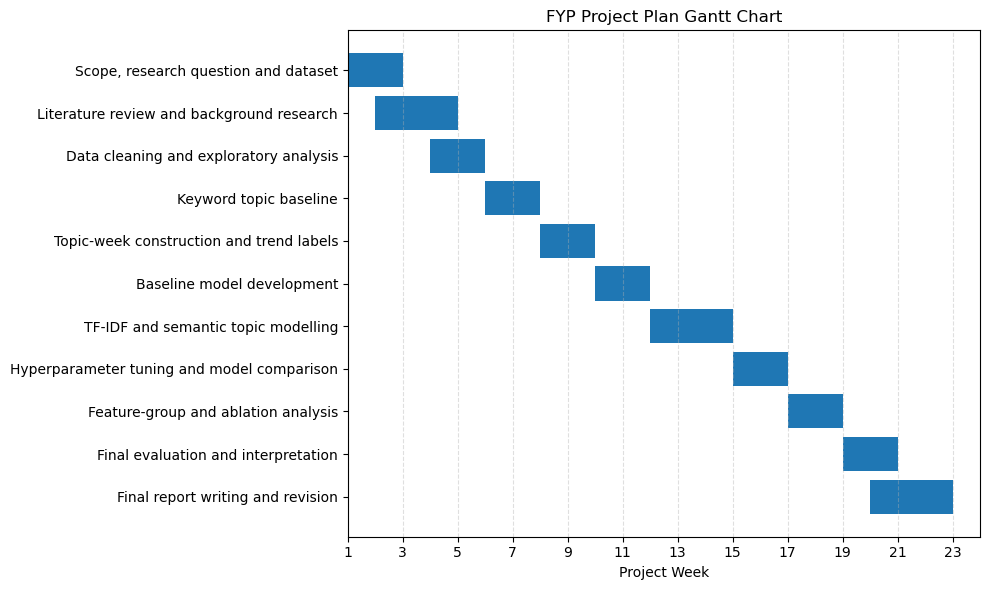

,Task,Start,Duration
0,"Scope, research question and dataset",1,2
1,Literature review and background research,2,3
2,Data cleaning and exploratory analysis,4,2
3,Keyword topic baseline,6,2
4,Topic-week construction and trend labels,8,2
5,Baseline model development,10,2
6,TF-IDF and semantic topic modelling,12,3
7,Hyperparameter tuning and model comparison,15,2
8,Feature-group and ablation analysis,17,2
9,Final evaluation and interpretation,19,2


In [110]:
# Create a simple Gantt chart for the project report
# Updated project plan reflecting the completed development stages
project_tasks = pd.DataFrame([
    {
        "Task": "Scope, research question and dataset",
        "Start": 1,
        "Duration": 2
    },
    {
        "Task": "Literature review and background research",
        "Start": 2,
        "Duration": 3
    },
    {
        "Task": "Data cleaning and exploratory analysis",
        "Start": 4,
        "Duration": 2
    },
    {
        "Task": "Keyword topic baseline",
        "Start": 6,
        "Duration": 2
    },
    {
        "Task": "Topic-week construction and trend labels",
        "Start": 8,
        "Duration": 2
    },
    {
        "Task": "Baseline model development",
        "Start": 10,
        "Duration": 2
    },
    {
        "Task": "TF-IDF and semantic topic modelling",
        "Start": 12,
        "Duration": 3
    },
    {
        "Task": "Hyperparameter tuning and model comparison",
        "Start": 15,
        "Duration": 2
    },
    {
        "Task": "Feature-group and ablation analysis",
        "Start": 17,
        "Duration": 2
    },
    {
        "Task": "Final evaluation and interpretation",
        "Start": 19,
        "Duration": 2
    },
    {
        "Task": "Final report writing and revision",
        "Start": 20,
        "Duration": 3
    }
])

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(project_tasks))

ax.barh(y_positions, project_tasks["Duration"], left=project_tasks["Start"])
ax.set_yticks(y_positions)
ax.set_yticklabels(project_tasks["Task"])
ax.invert_yaxis()
ax.set_xlabel("Project Week")
ax.set_title("FYP Project Plan Gantt Chart")
ax.set_xlim(1, 24)
ax.set_xticks(range(1, 24, 2))
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("figure_gantt_chart.png", dpi=200, bbox_inches="tight")
plt.show()

project_tasks